# [LAB 08] 2. 데이터 시각화
## #연습문제

![alt text](image.png)

In [33]:
%%capture cap
%run "./08. PBT - EDAㅣ1-EDA 시작하기(연습문제).ipynb"

In [34]:
print("목표변수 :", target)
print("연속형(종속변수 포함):", continuous_cols)
print('독립변수(명목형):', nominal_cols)
print('독립변수(연속형):', feature_continuous)

display(df.head())
display(desc.head())
display(cat_desc.head())

목표변수 : charges
연속형(종속변수 포함): ['age', 'bmi', 'children', 'charges']
독립변수(명목형): ['sex', 'smoker', 'region']
독립변수(연속형): ['age', 'bmi', 'children']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
age,1337.000,39.222,14.044,18.000,27.000,39.000,51.000,64.000,0.006,similar,24.000,87.000,-9.000,0,0.000,0,0.000,0,0.000,0.055,symmetric,-1.244,platykurtic,none
bmi,1337.000,30.663,6.100,15.960,26.290,30.400,34.700,53.130,0.009,similar,8.410,47.315,13.675,9,0.007,0,0.000,9,0.007,0.284,symmetric,-0.053,platykurtic,none
children,1337.000,1.096,1.206,0.000,0.000,1.000,2.000,5.000,0.096,similar,2.000,5.000,-3.000,0,0.000,0,0.000,0,0.000,0.937,right tail,0.201,leptokurtic,log1p
charges,1337.000,13279.121,12110.360,1121.874,4746.344,9386.161,16657.717,63770.428,0.415,diff,11911.373,34524.778,-13120.716,139,0.104,0,0.000,139,0.104,1.515,right tail,1.604,leptokurtic,log1p


,Unnamed: 0,sex,smoker,region
0,count,1337,1337,1337
1,unique,2,2,4
2,top,male,no,southeast
3,freq,675,1063,364


# 종속변수

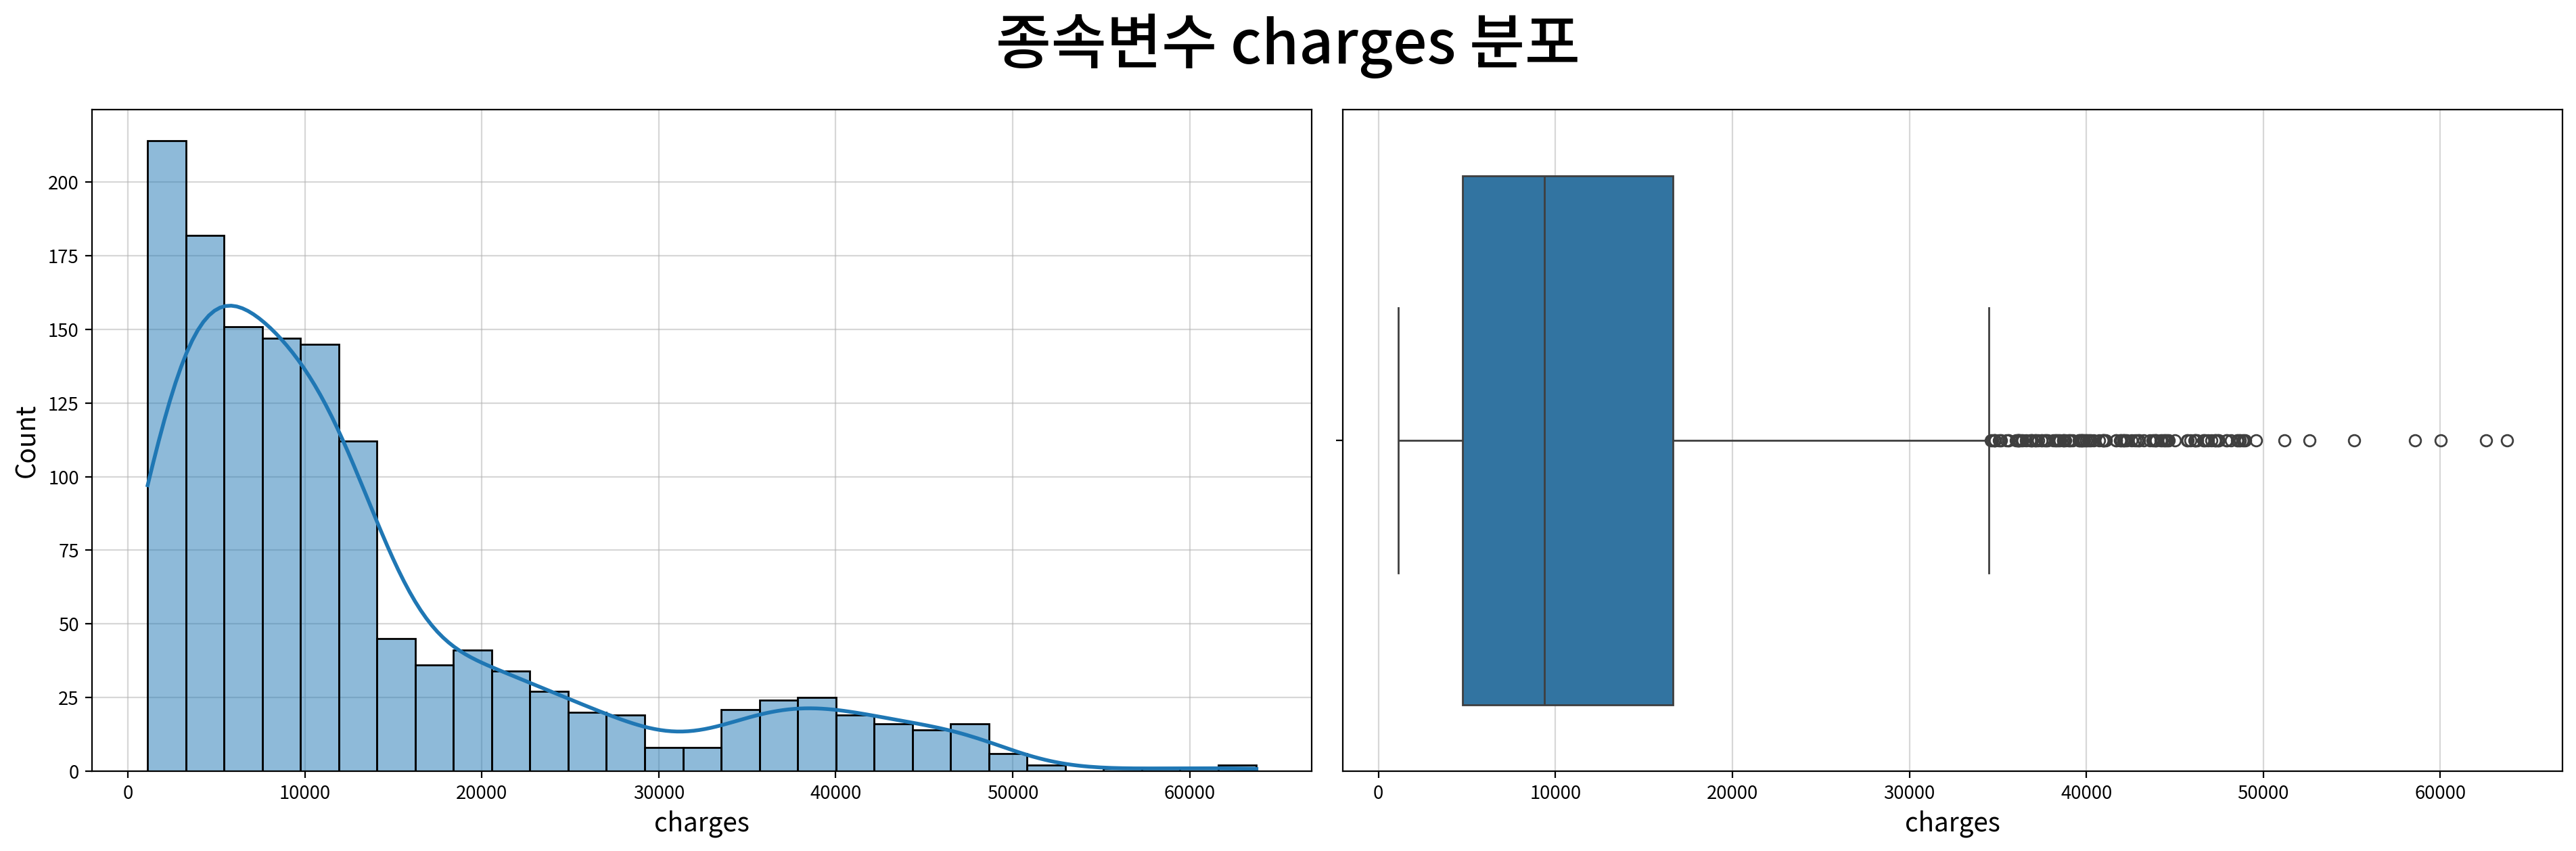

In [35]:
fig, ax = my_plot.init(rows=1, cols=2, title=f'종속변수 {target} 분포', width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

|점검항목|charges 관찰내용|
|-|-|
|분포모양(왜도)|오른쪽으로 치우침(우편향)|
|봉우리 수|낮은 보험료 구간에 1개 존재|
|이상치(박스플롯)|위쪽 수염 밖에 점 다수 존재|
|이산점(군집)|낮은 보험료 구간에 데이터가 집중되고, 높은 보험료 구간에 데이터 다소 분포|

- charges는 낮은 보험료 구간에 값이 많이 몰려 있고, 오른쪽으로 긴 꼬리를 갖는 우편향 분포이다. 
- 박스플롯에서도 위쪽 수염 밖에 높은 보험료 구간에 이상치가 확인되므로, 모델링 시 로그 변환(log1p)을 적용하는 것이 적절해보인다.

#### 연속형 독립변수

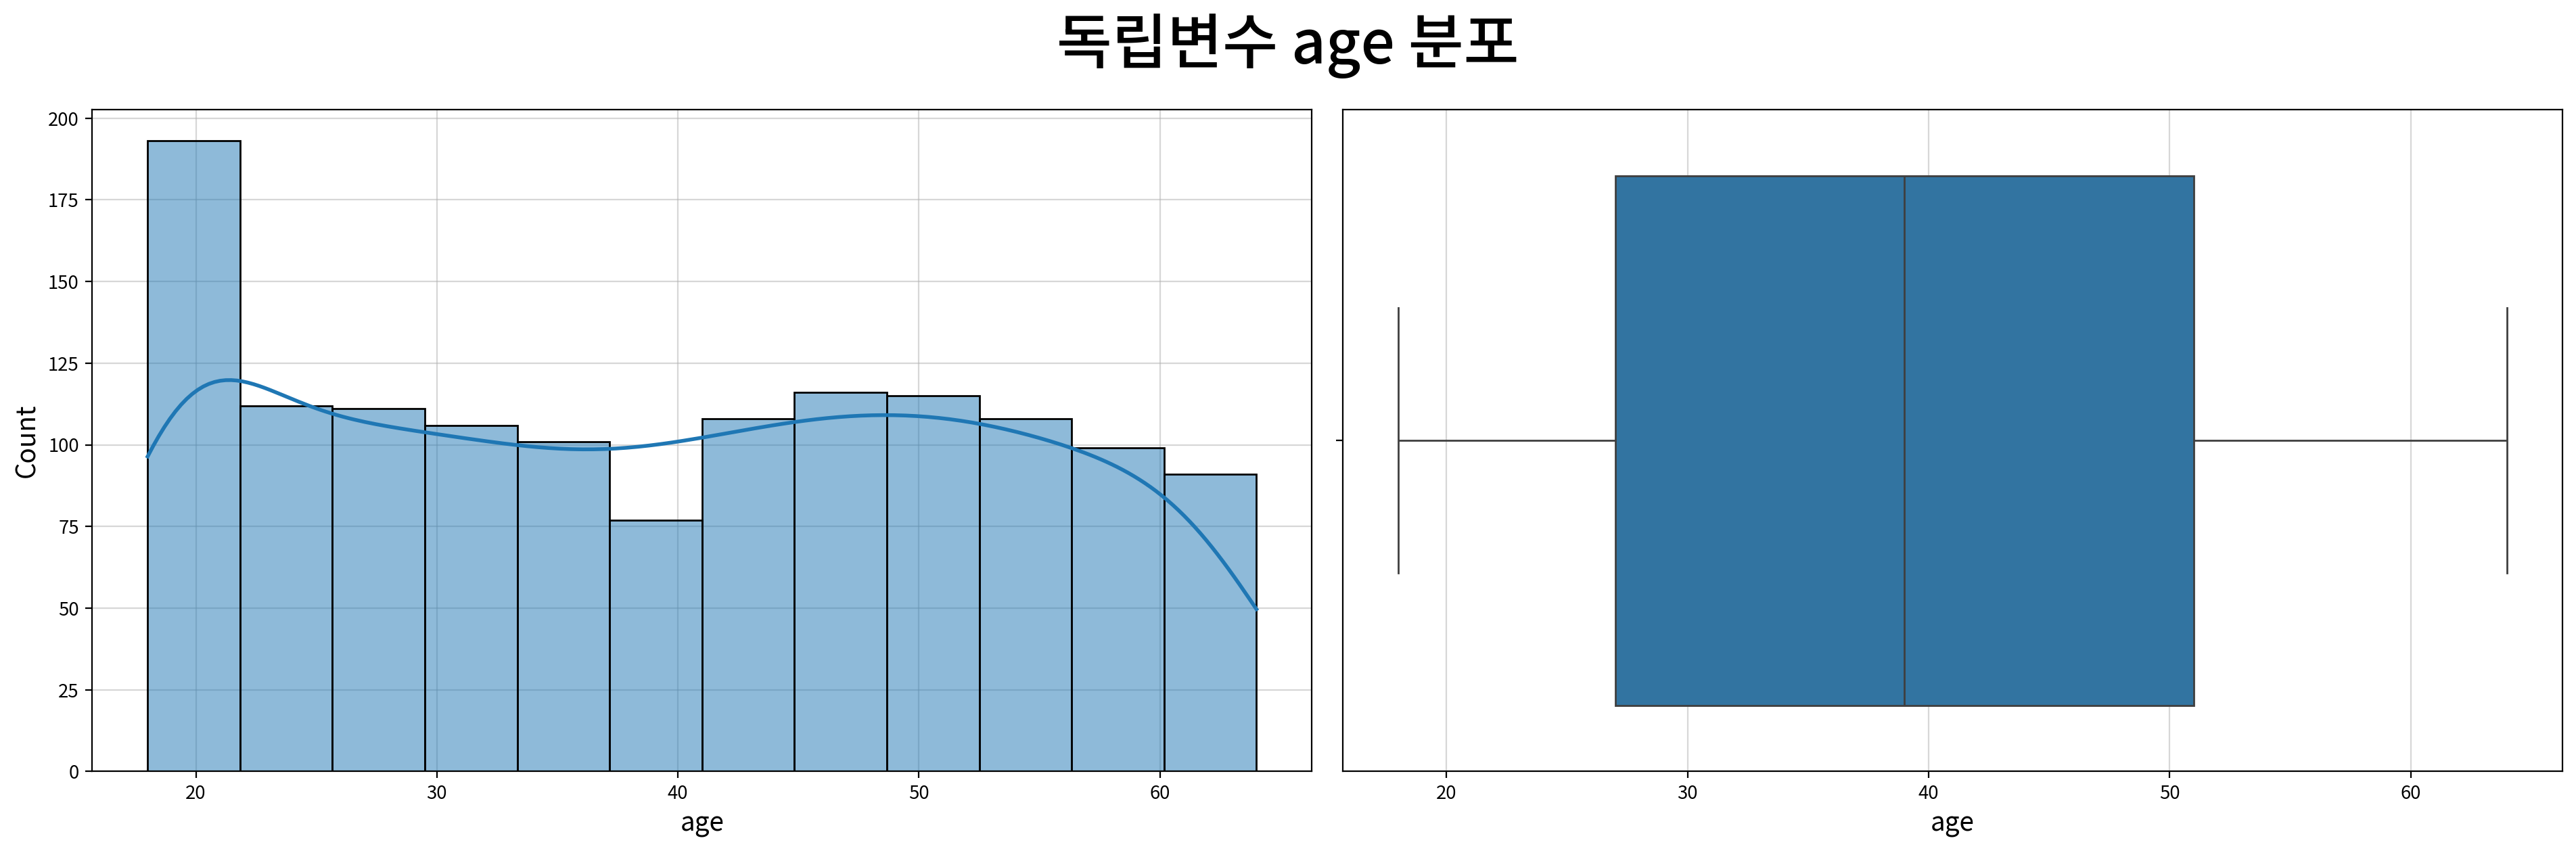

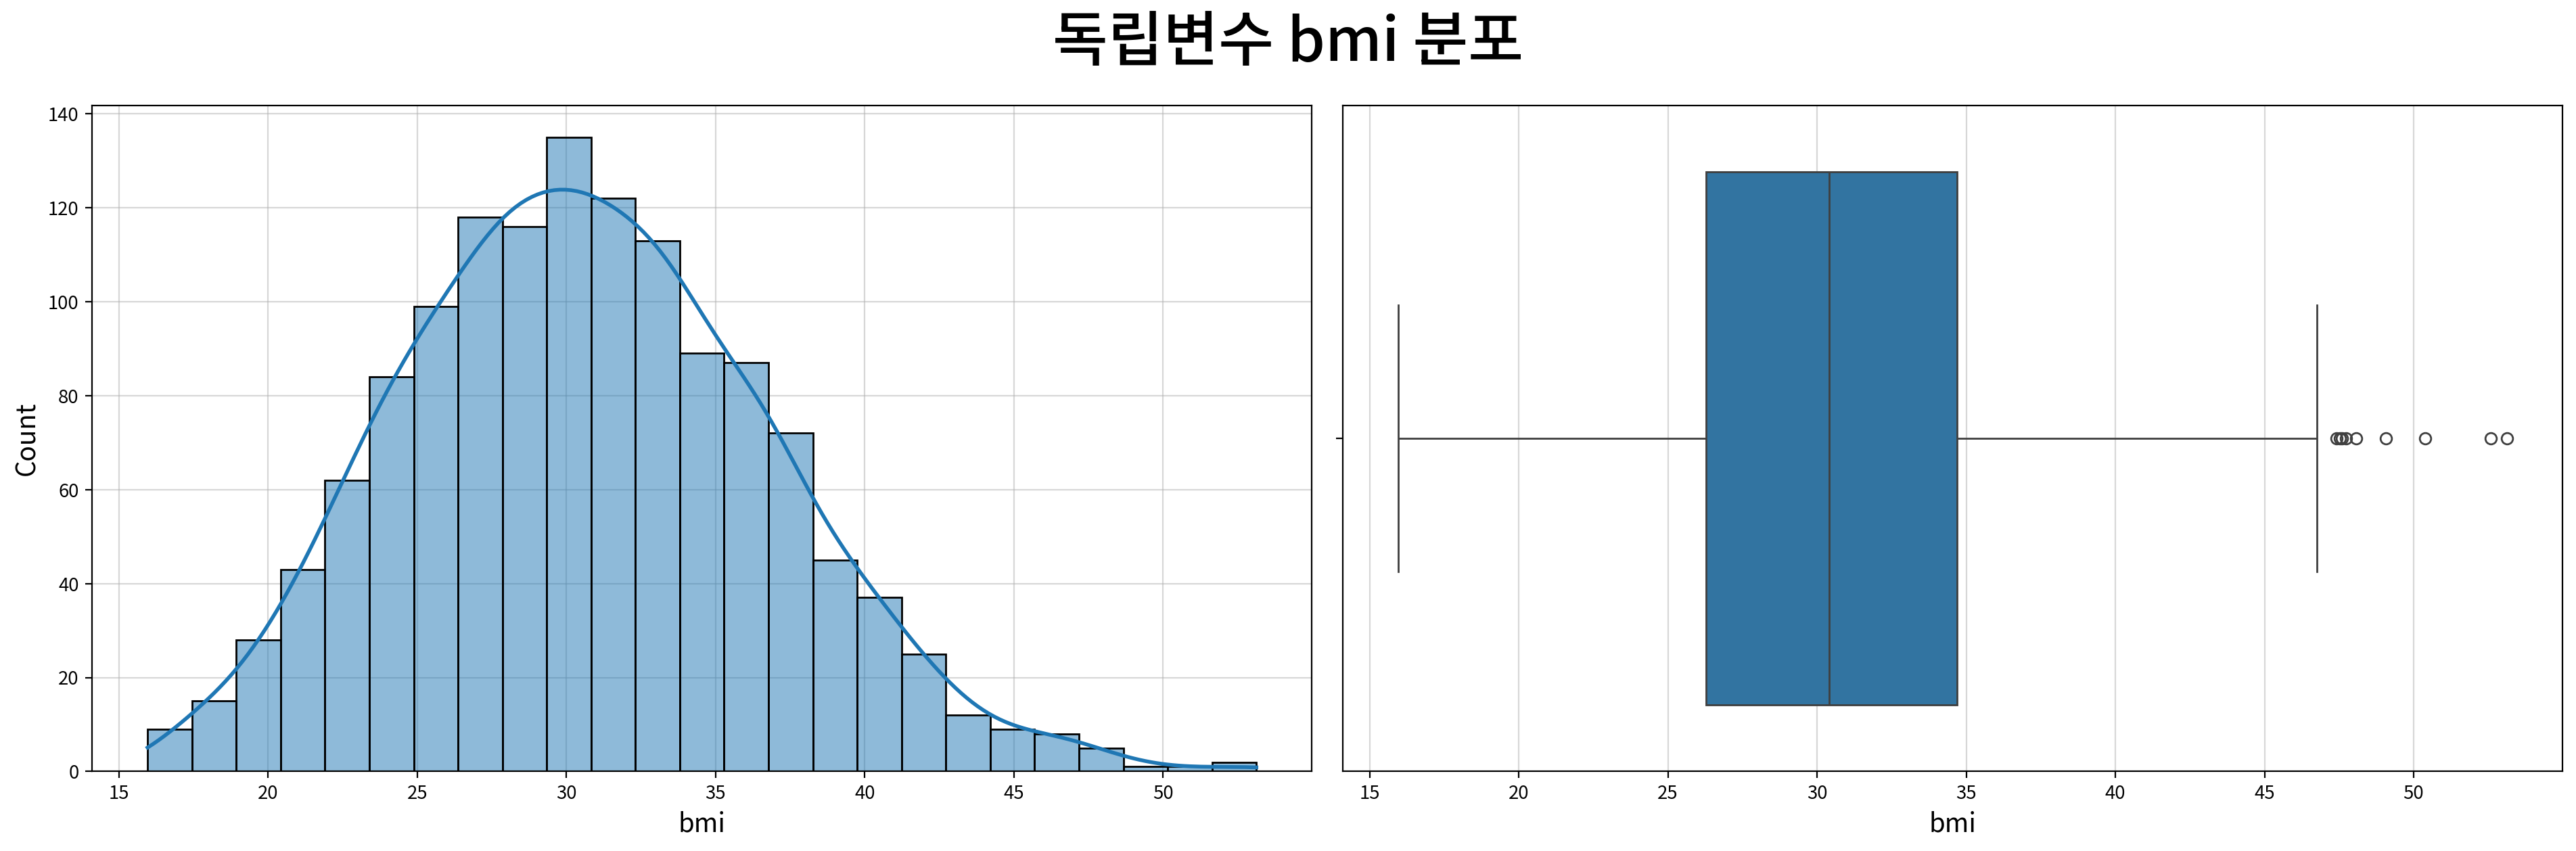

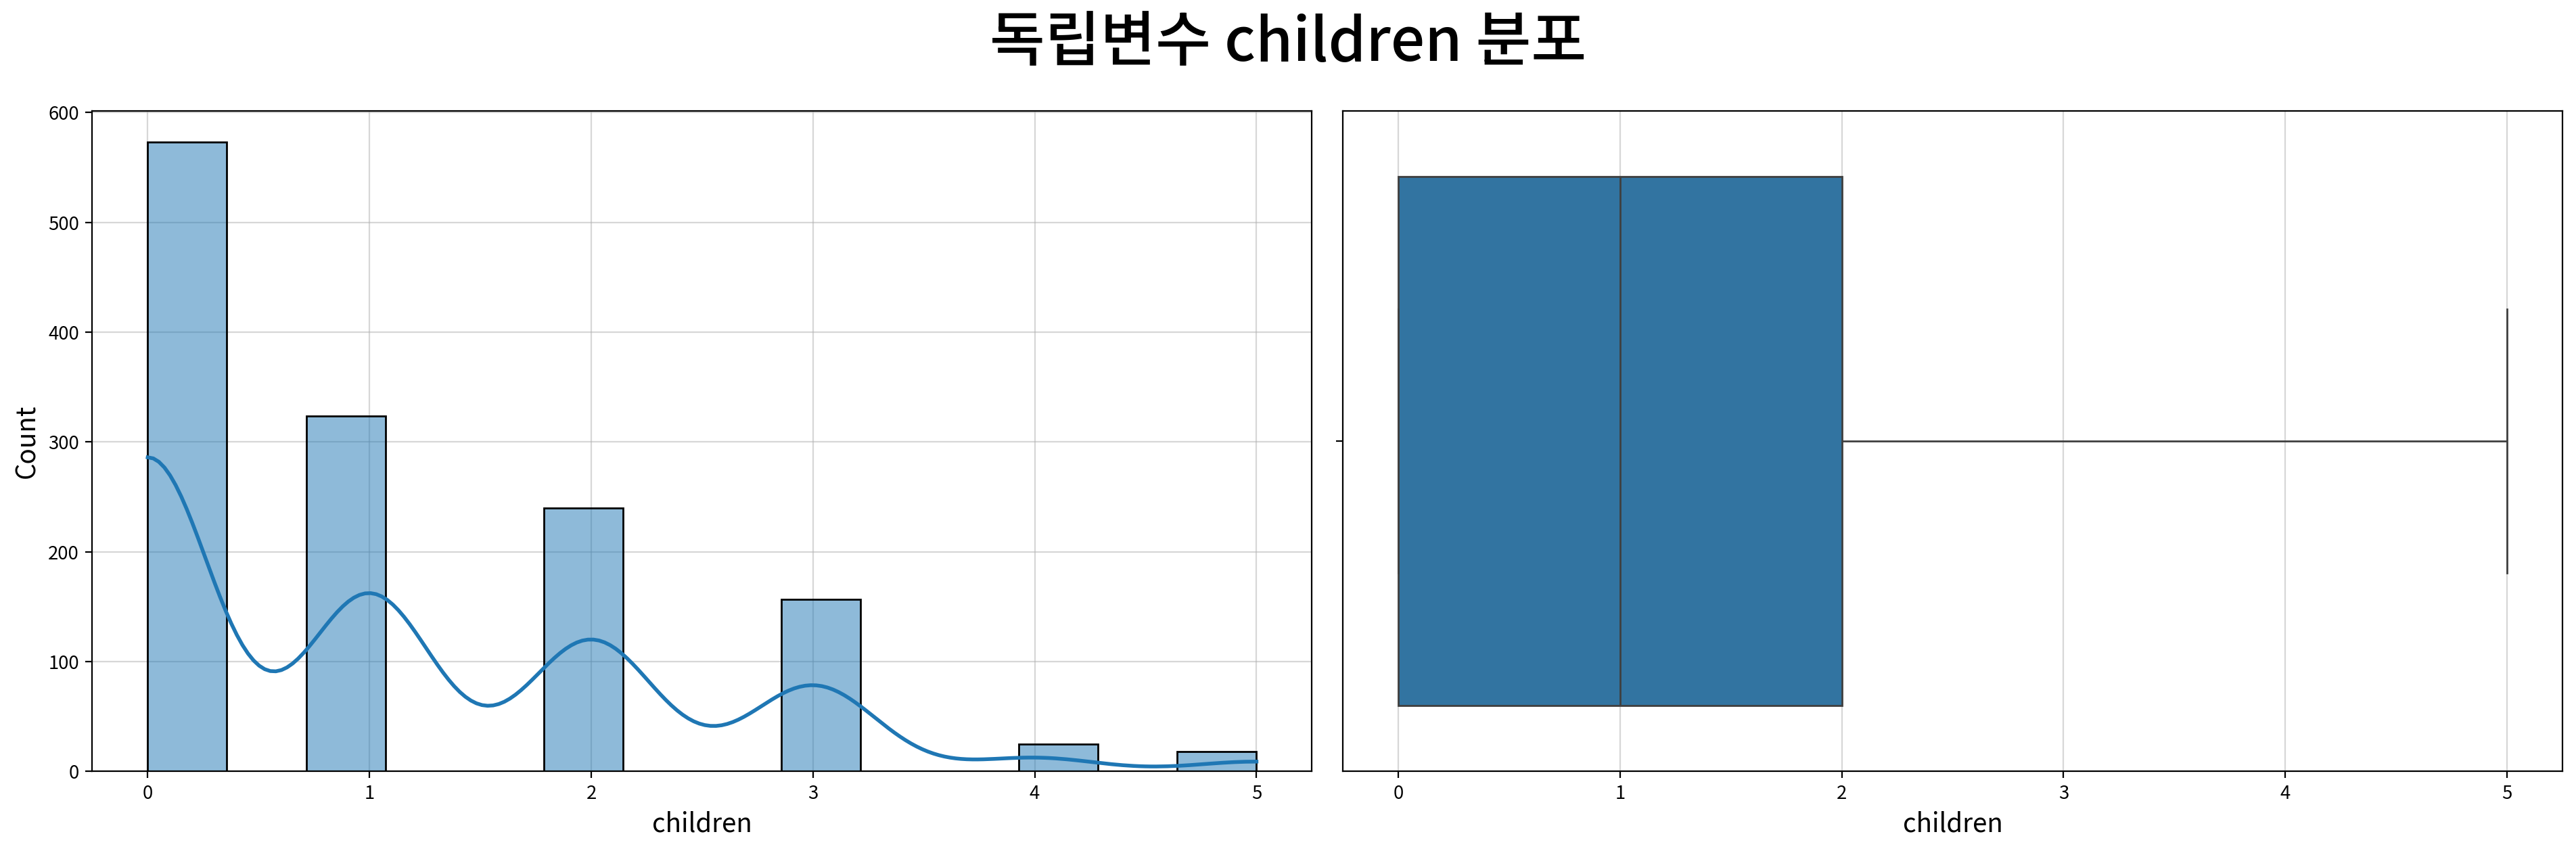

In [36]:
for f in feature_continuous:
    fig, ax = my_plot.init(rows=1, cols=2, title=f'독립변수 {f} 분포', width=960, height=640)
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

- 인사이트

| 변수 | 분포모양 | 봉우리 | 이상치 | 이산점(군집) | 판단/조치 |
|-|-|-|-|-|-|
| age | 뚜렷한 좌우 치우침은 크지 않음 | 단봉 | 없음 | - | 그대로 사용 가능 |
| bmi | 약한 우편향 | 단봉 | 위쪽 수염 밖에 일부 점 존재 | - | 그대로 사용 가능 |
| children | 우편향 | 많음, 0명에 가장 많음 | 없음 | 0~5명으로 값이 분리 | 그대로 사용 가능 |

#### 명목형

,빈도,비율(%)
sex,,
male,675,50.500
female,662,49.500


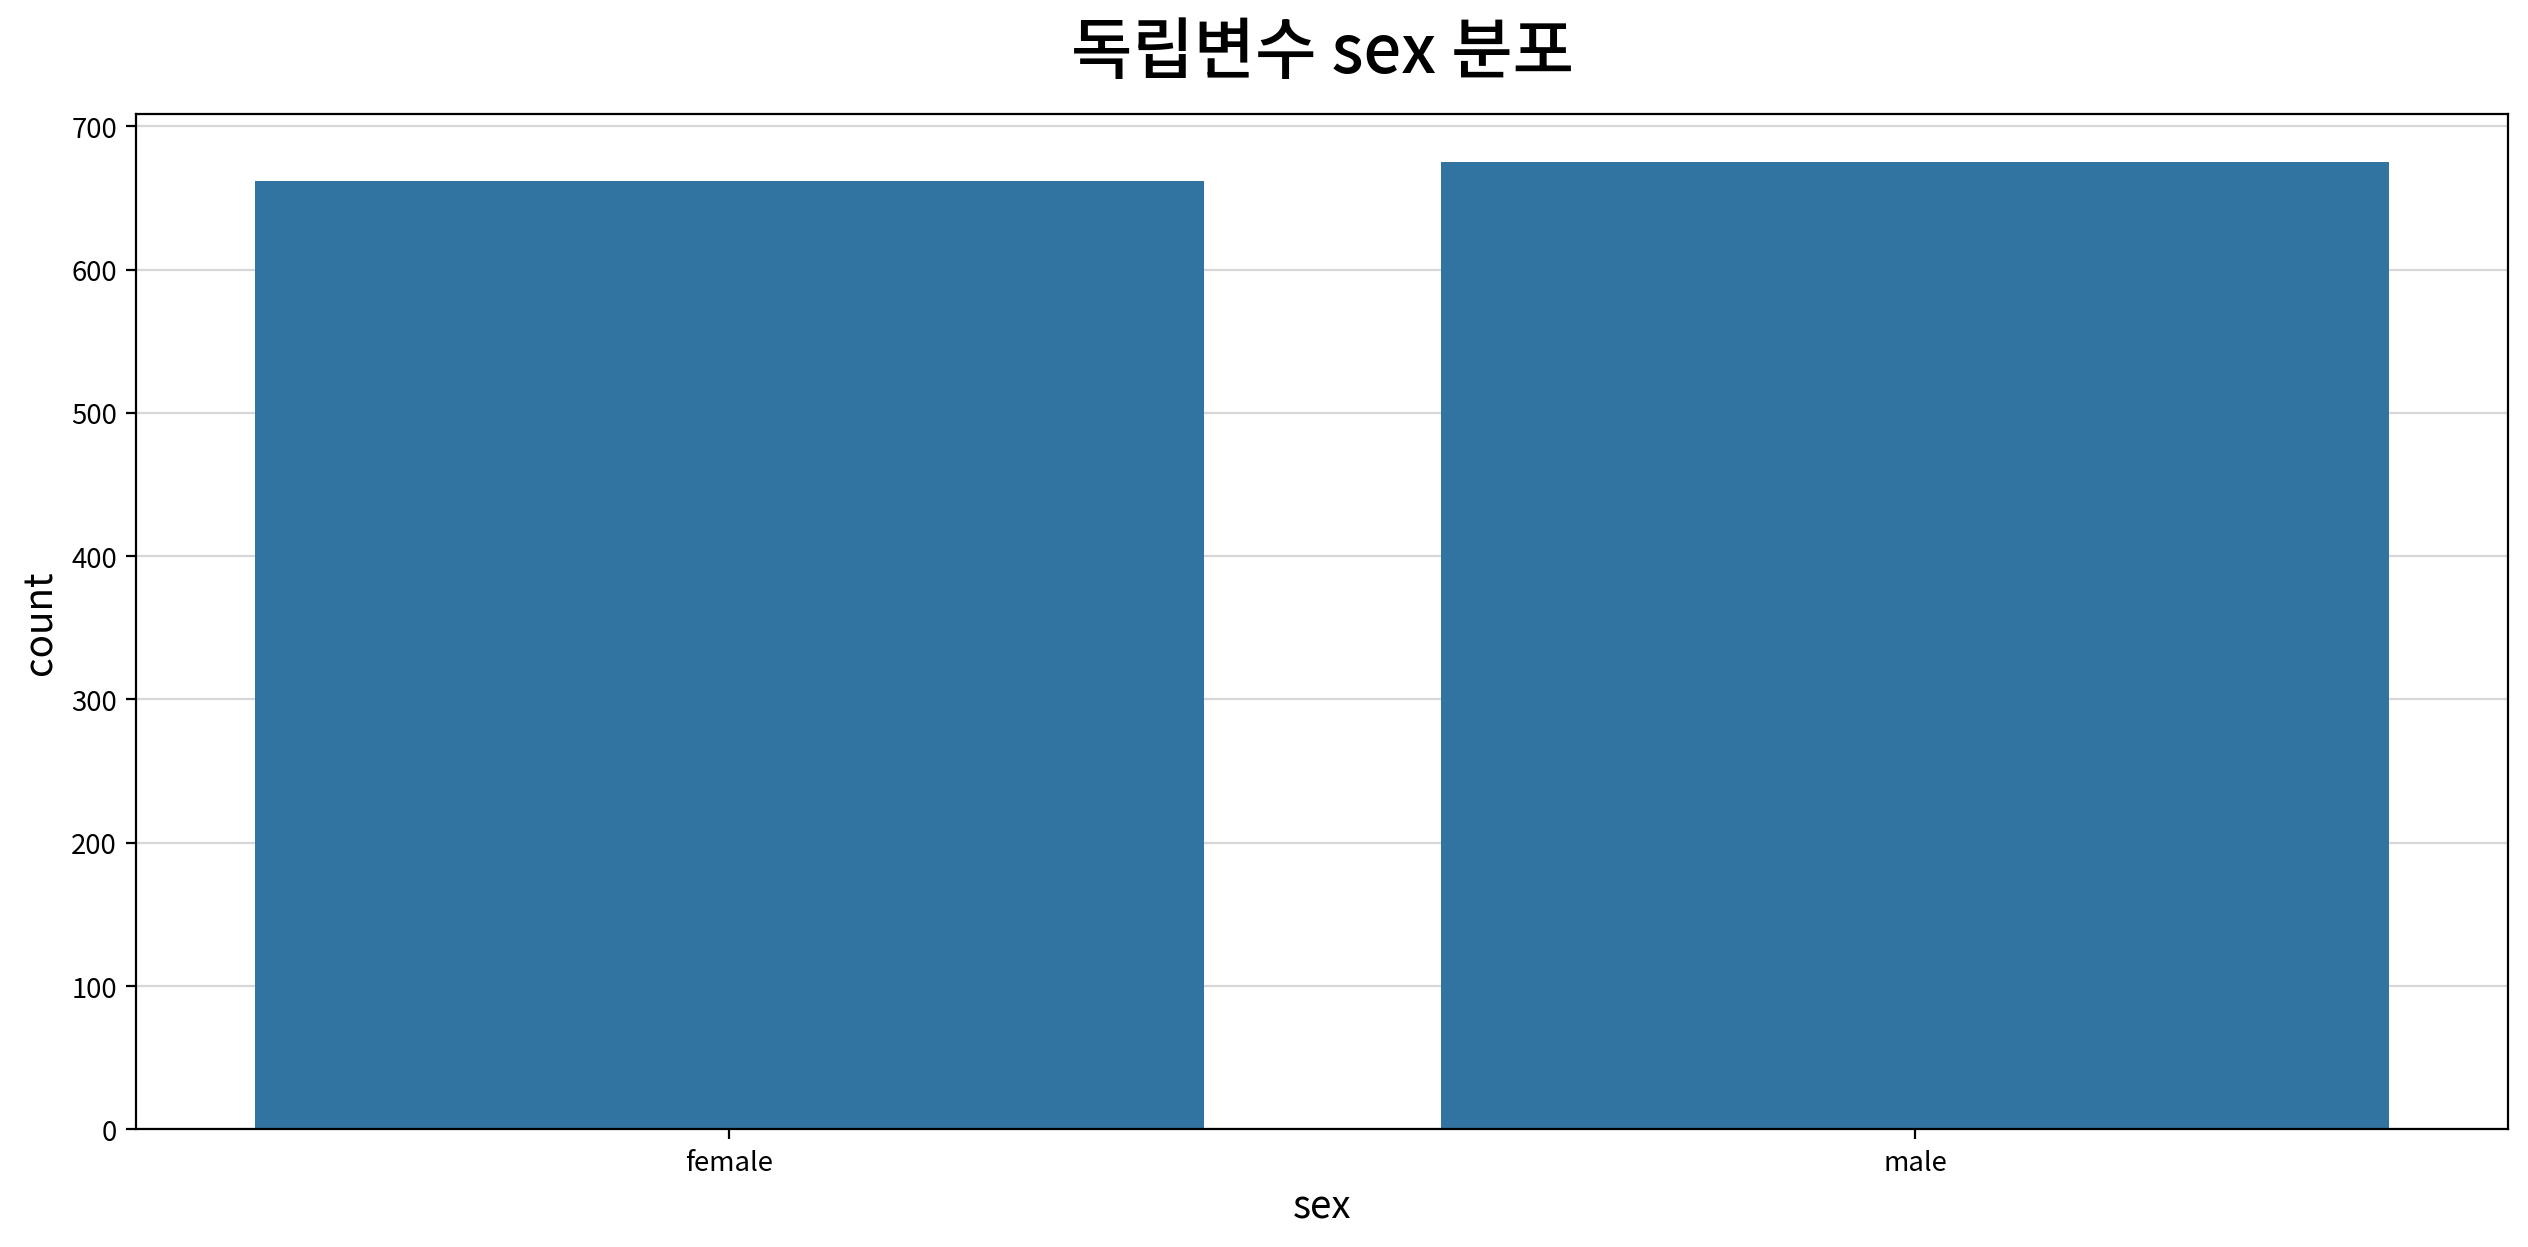

,빈도,비율(%)
smoker,,
no,1063,79.500
yes,274,20.500


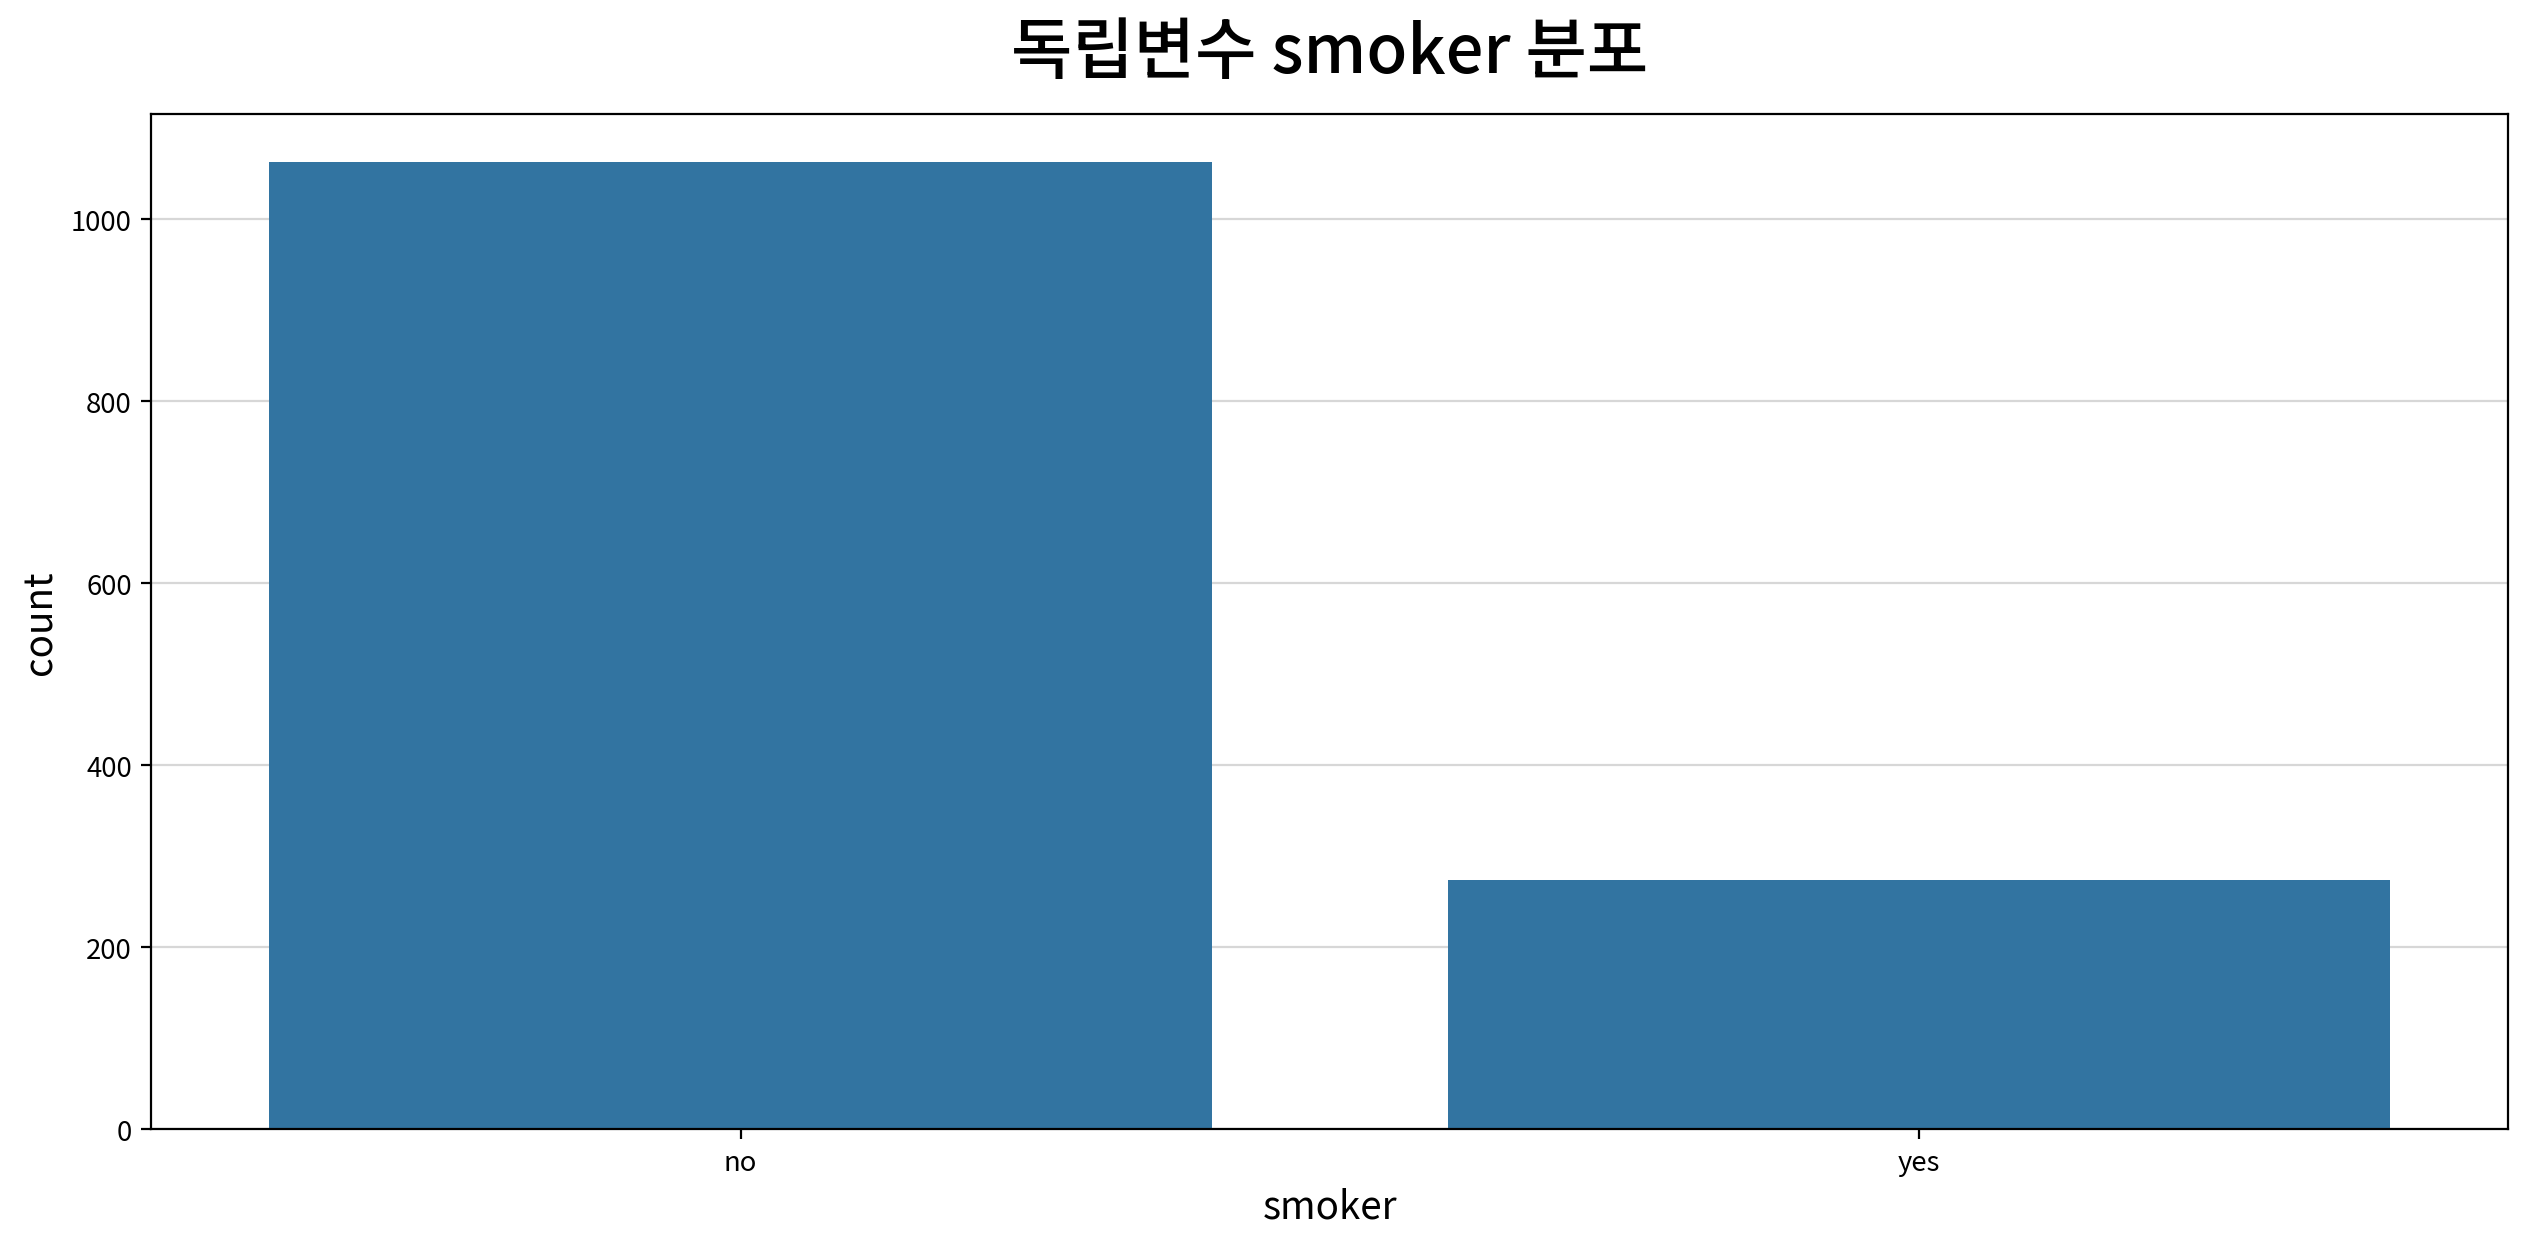

,빈도,비율(%)
region,,
southeast,364,27.200
southwest,325,24.300
northeast,324,24.200
northwest,324,24.200


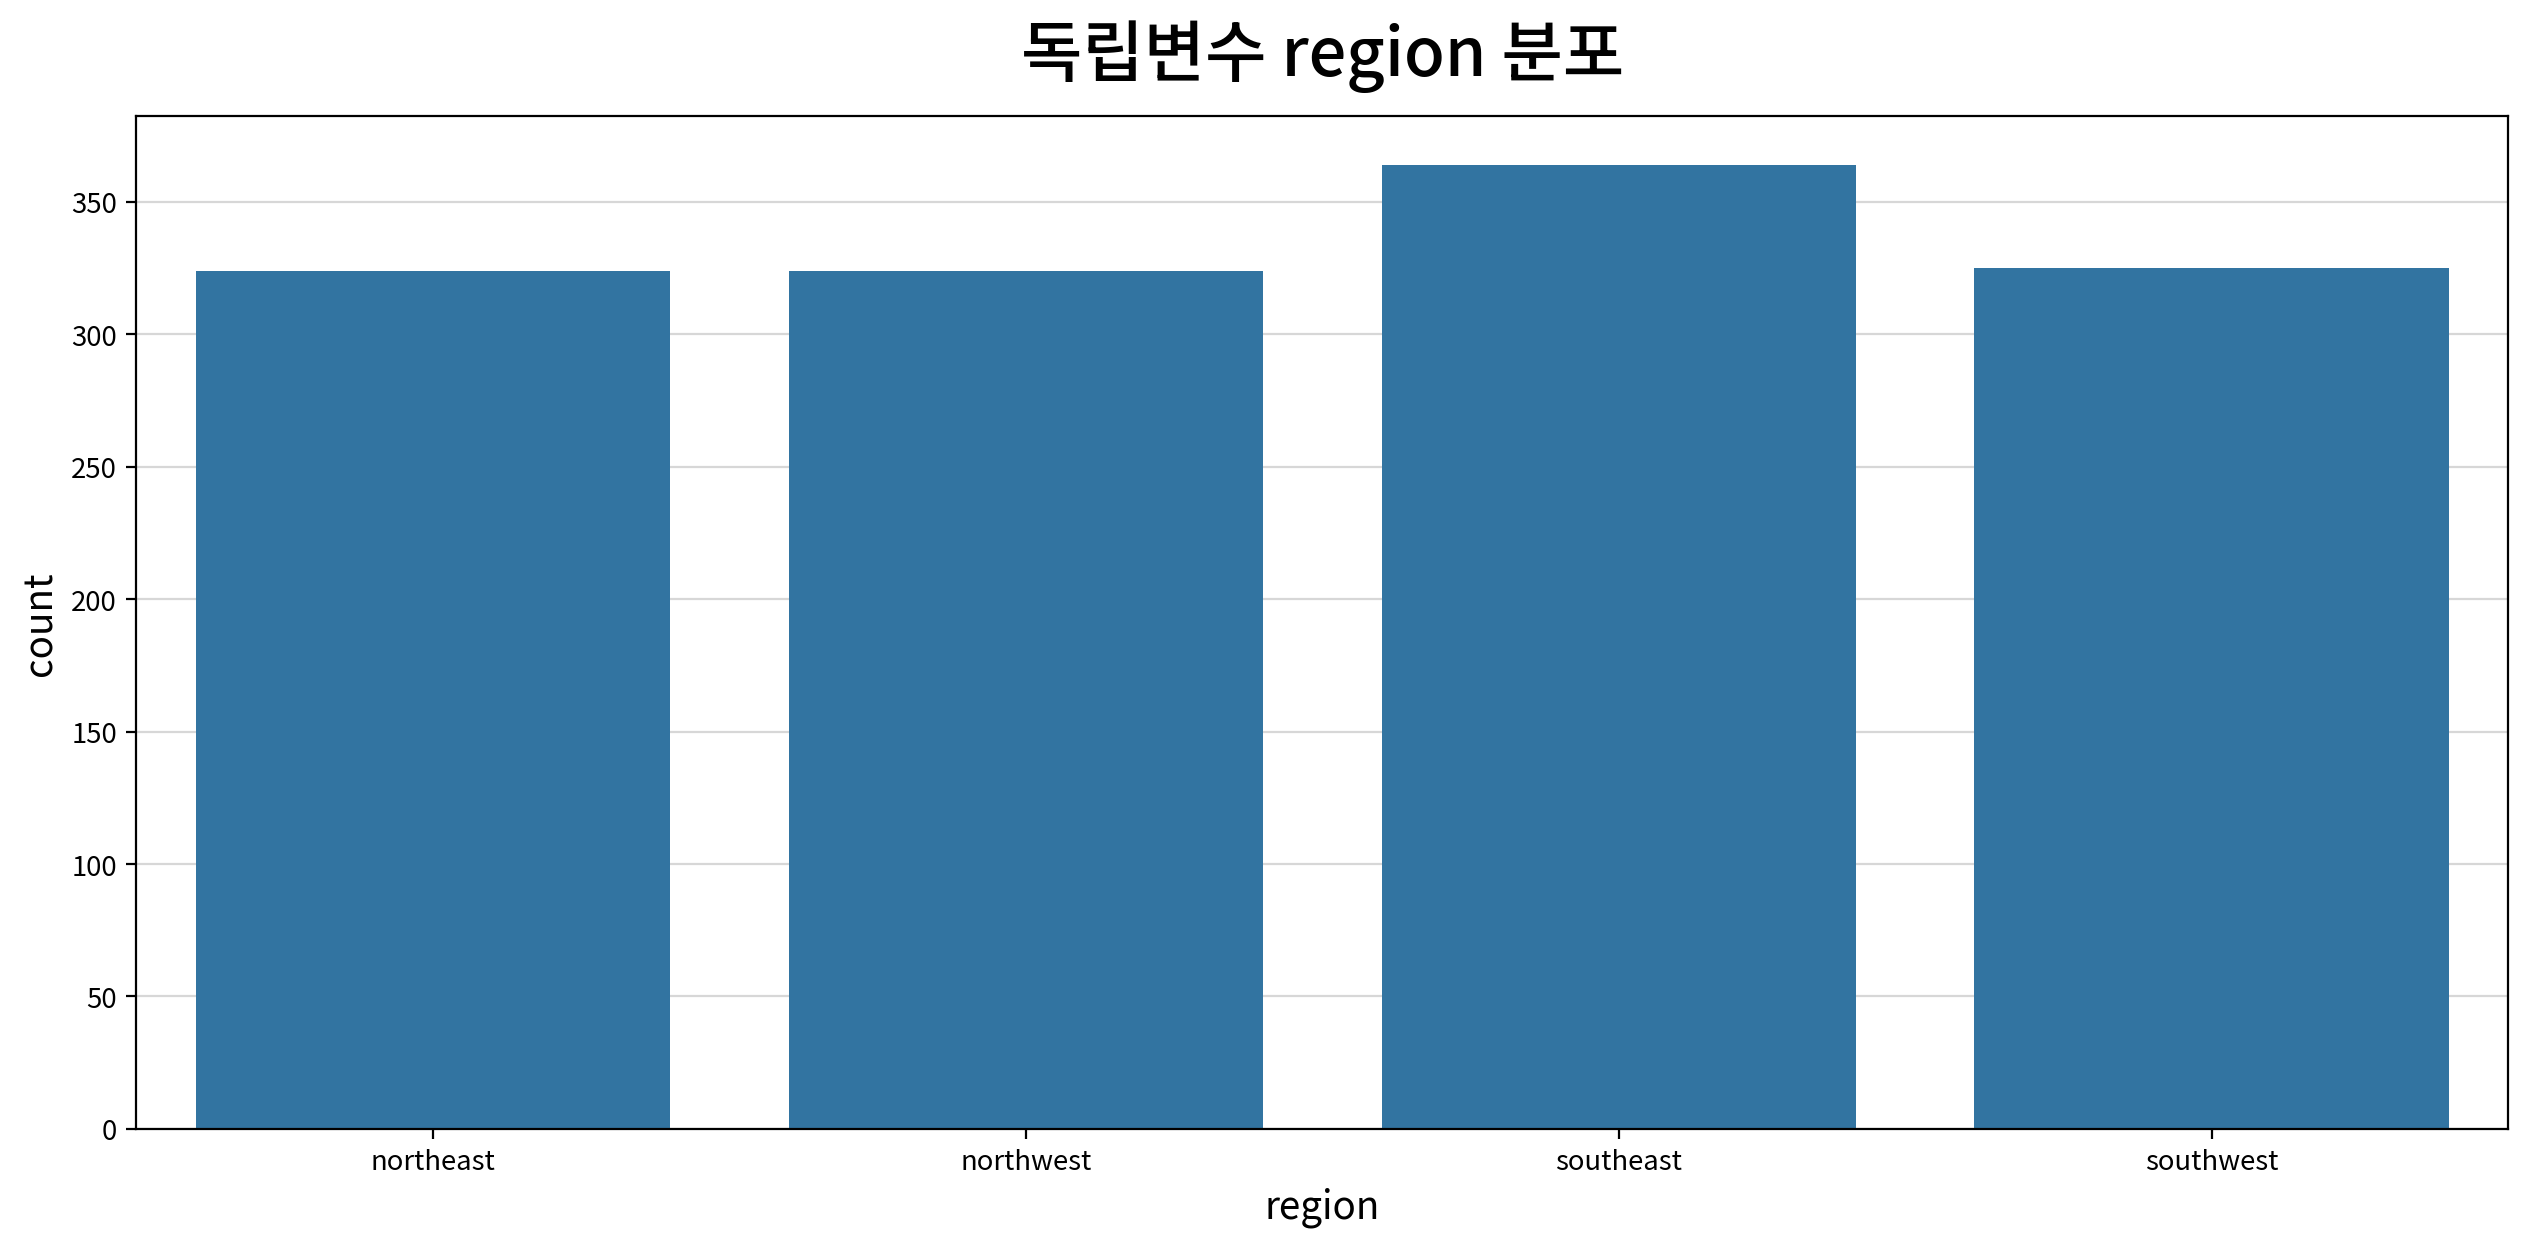

In [37]:
for n in nominal_cols:
    # 빈도표 - 명목형 분포를 수치로
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq['비율(%)'] = (df[n].value_counts(normalize=True) * 100).round(1)
    display(freq)

    # 명목형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, title=f'독립변수 {n} 분포')

- 인사이트
    - 명목형은 분포 모양, 왜도 대신 범주의 균형/불균형을 점검하여 그대로 검정/모델에 넣어도 되는가를 판단한다.

|변수|범주 수|빈도(비율)|균형 여부|판단/조치|
|-|-|-|-|-|
|sex|2 (male, female)|male: 675(50.5%), female: 662(49.5%)|균형|2집단이므로 charges와의 T검정 대상이며, 균형적이므로 그대로 사용 가능|
|smoker|2 (no, yes)|no: 1063(79.5%), yes: 274(20.5%)|불균형|2집단이므로 charges와의 T검정 대상|
|region|4 (northeast, northwest, southeast, southwest)|southeast: 364(27.2%), southwest: 325(24.3%), northwest: 325(24.3%), northeast: 323(24.2%)|대체로 균형|4집단이므로 charges와의 ANOVA 대상이며, 범주 비율이 비교적 균형적이므로 그대로 사용 가능|

#### 이변량 데이터 시각화

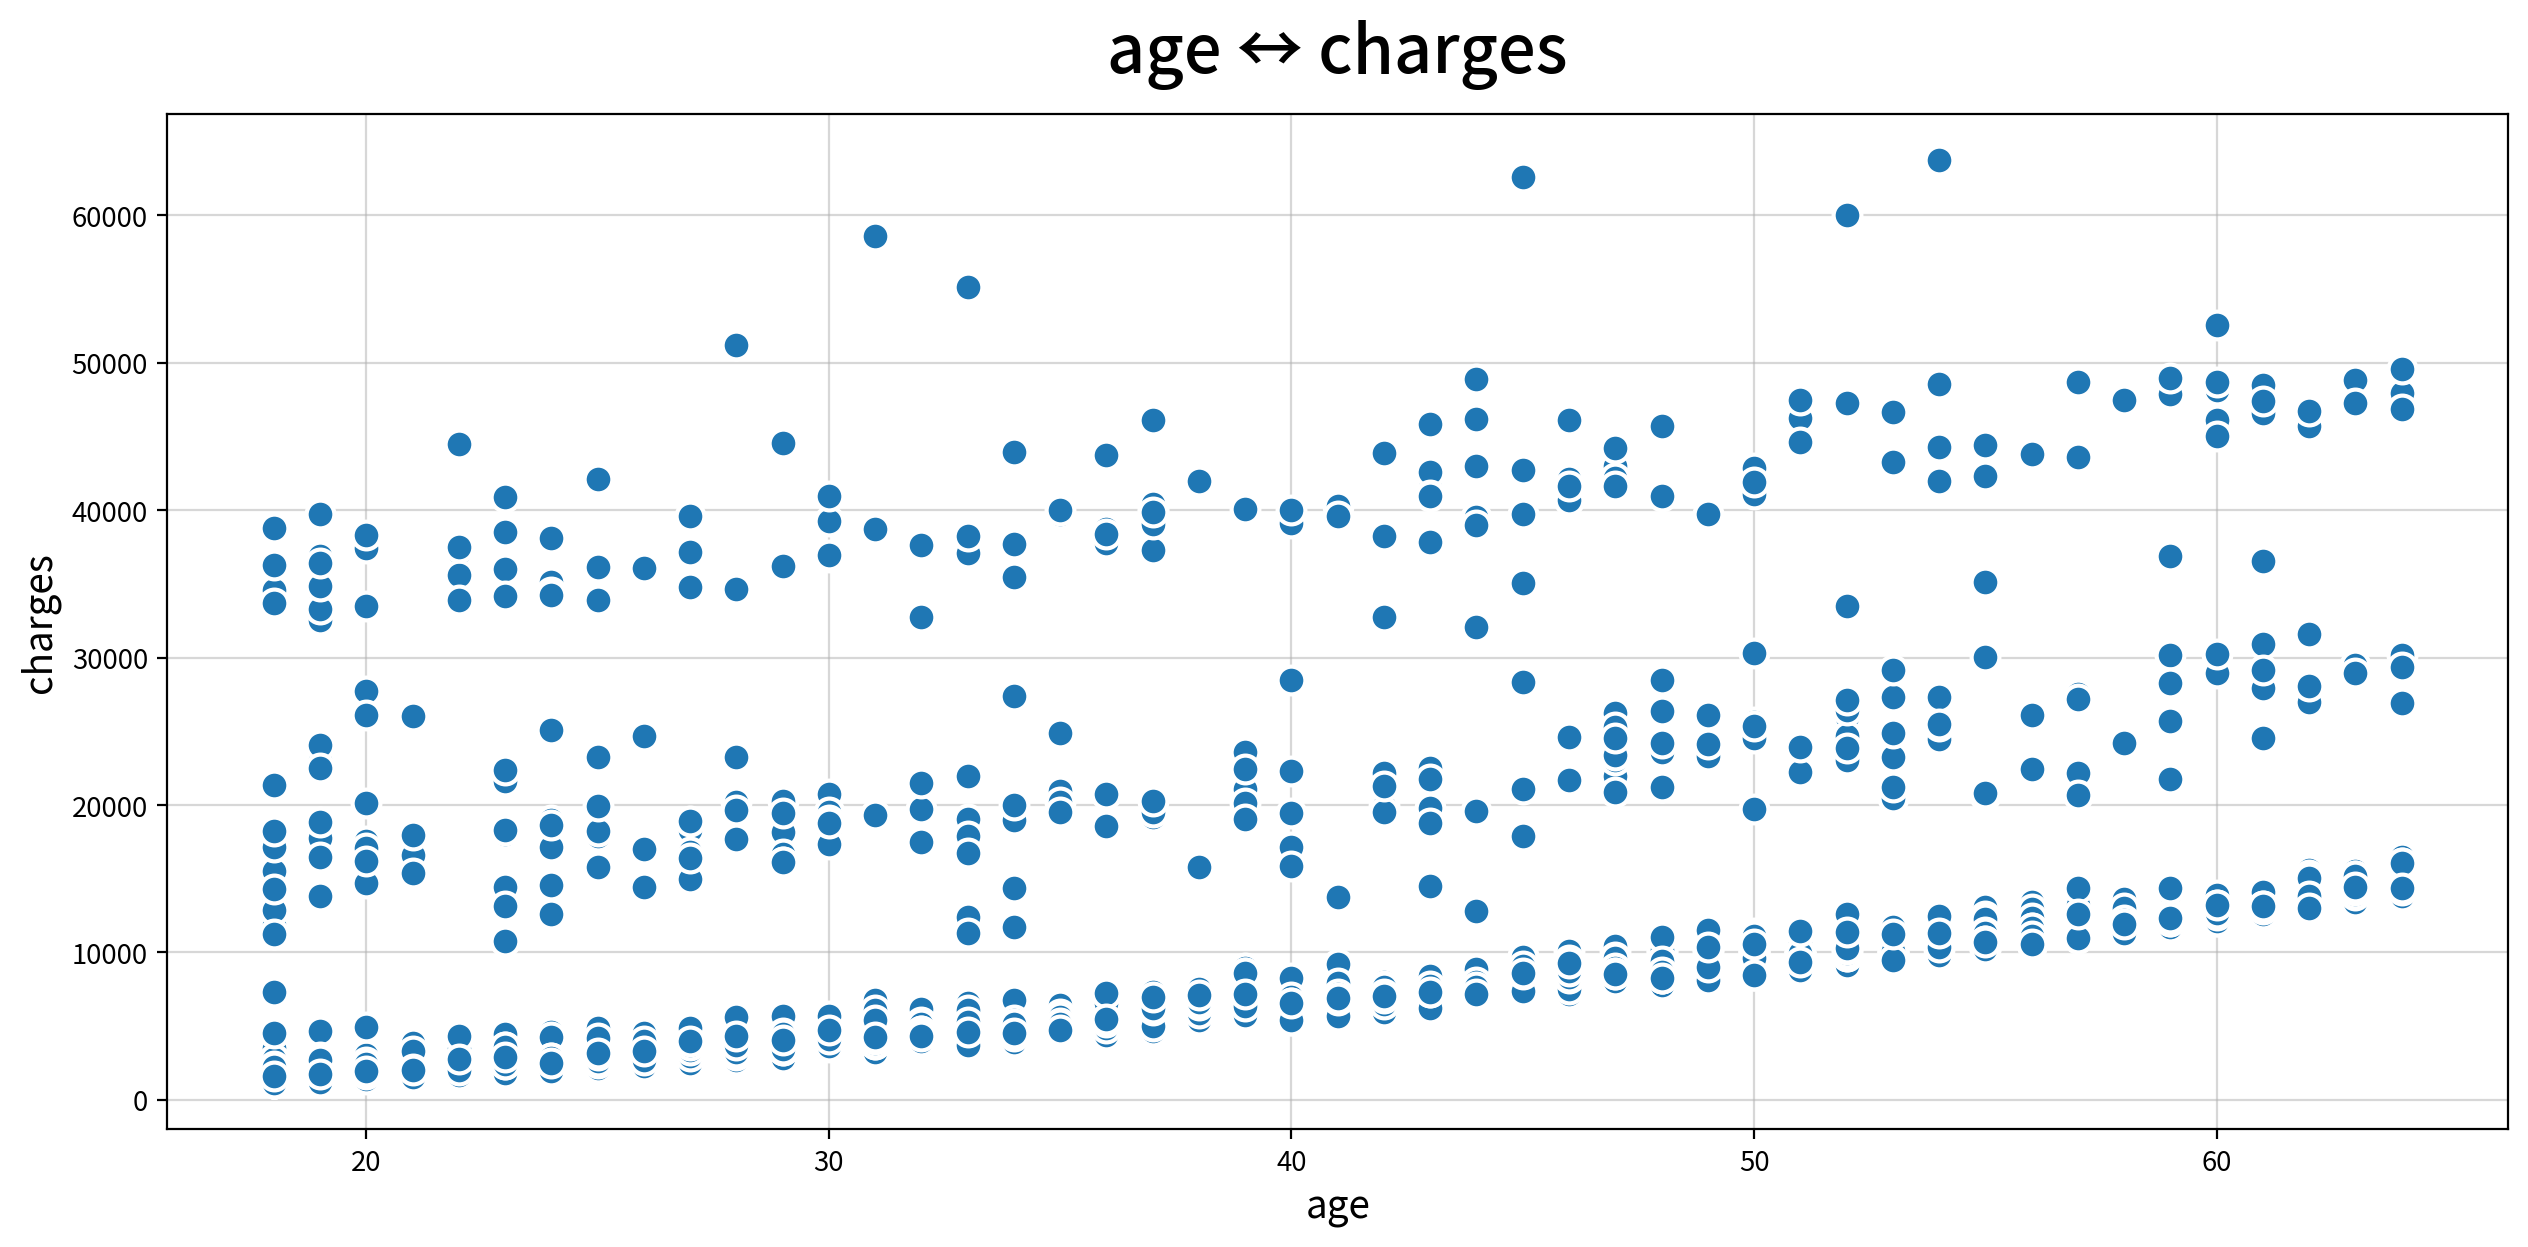

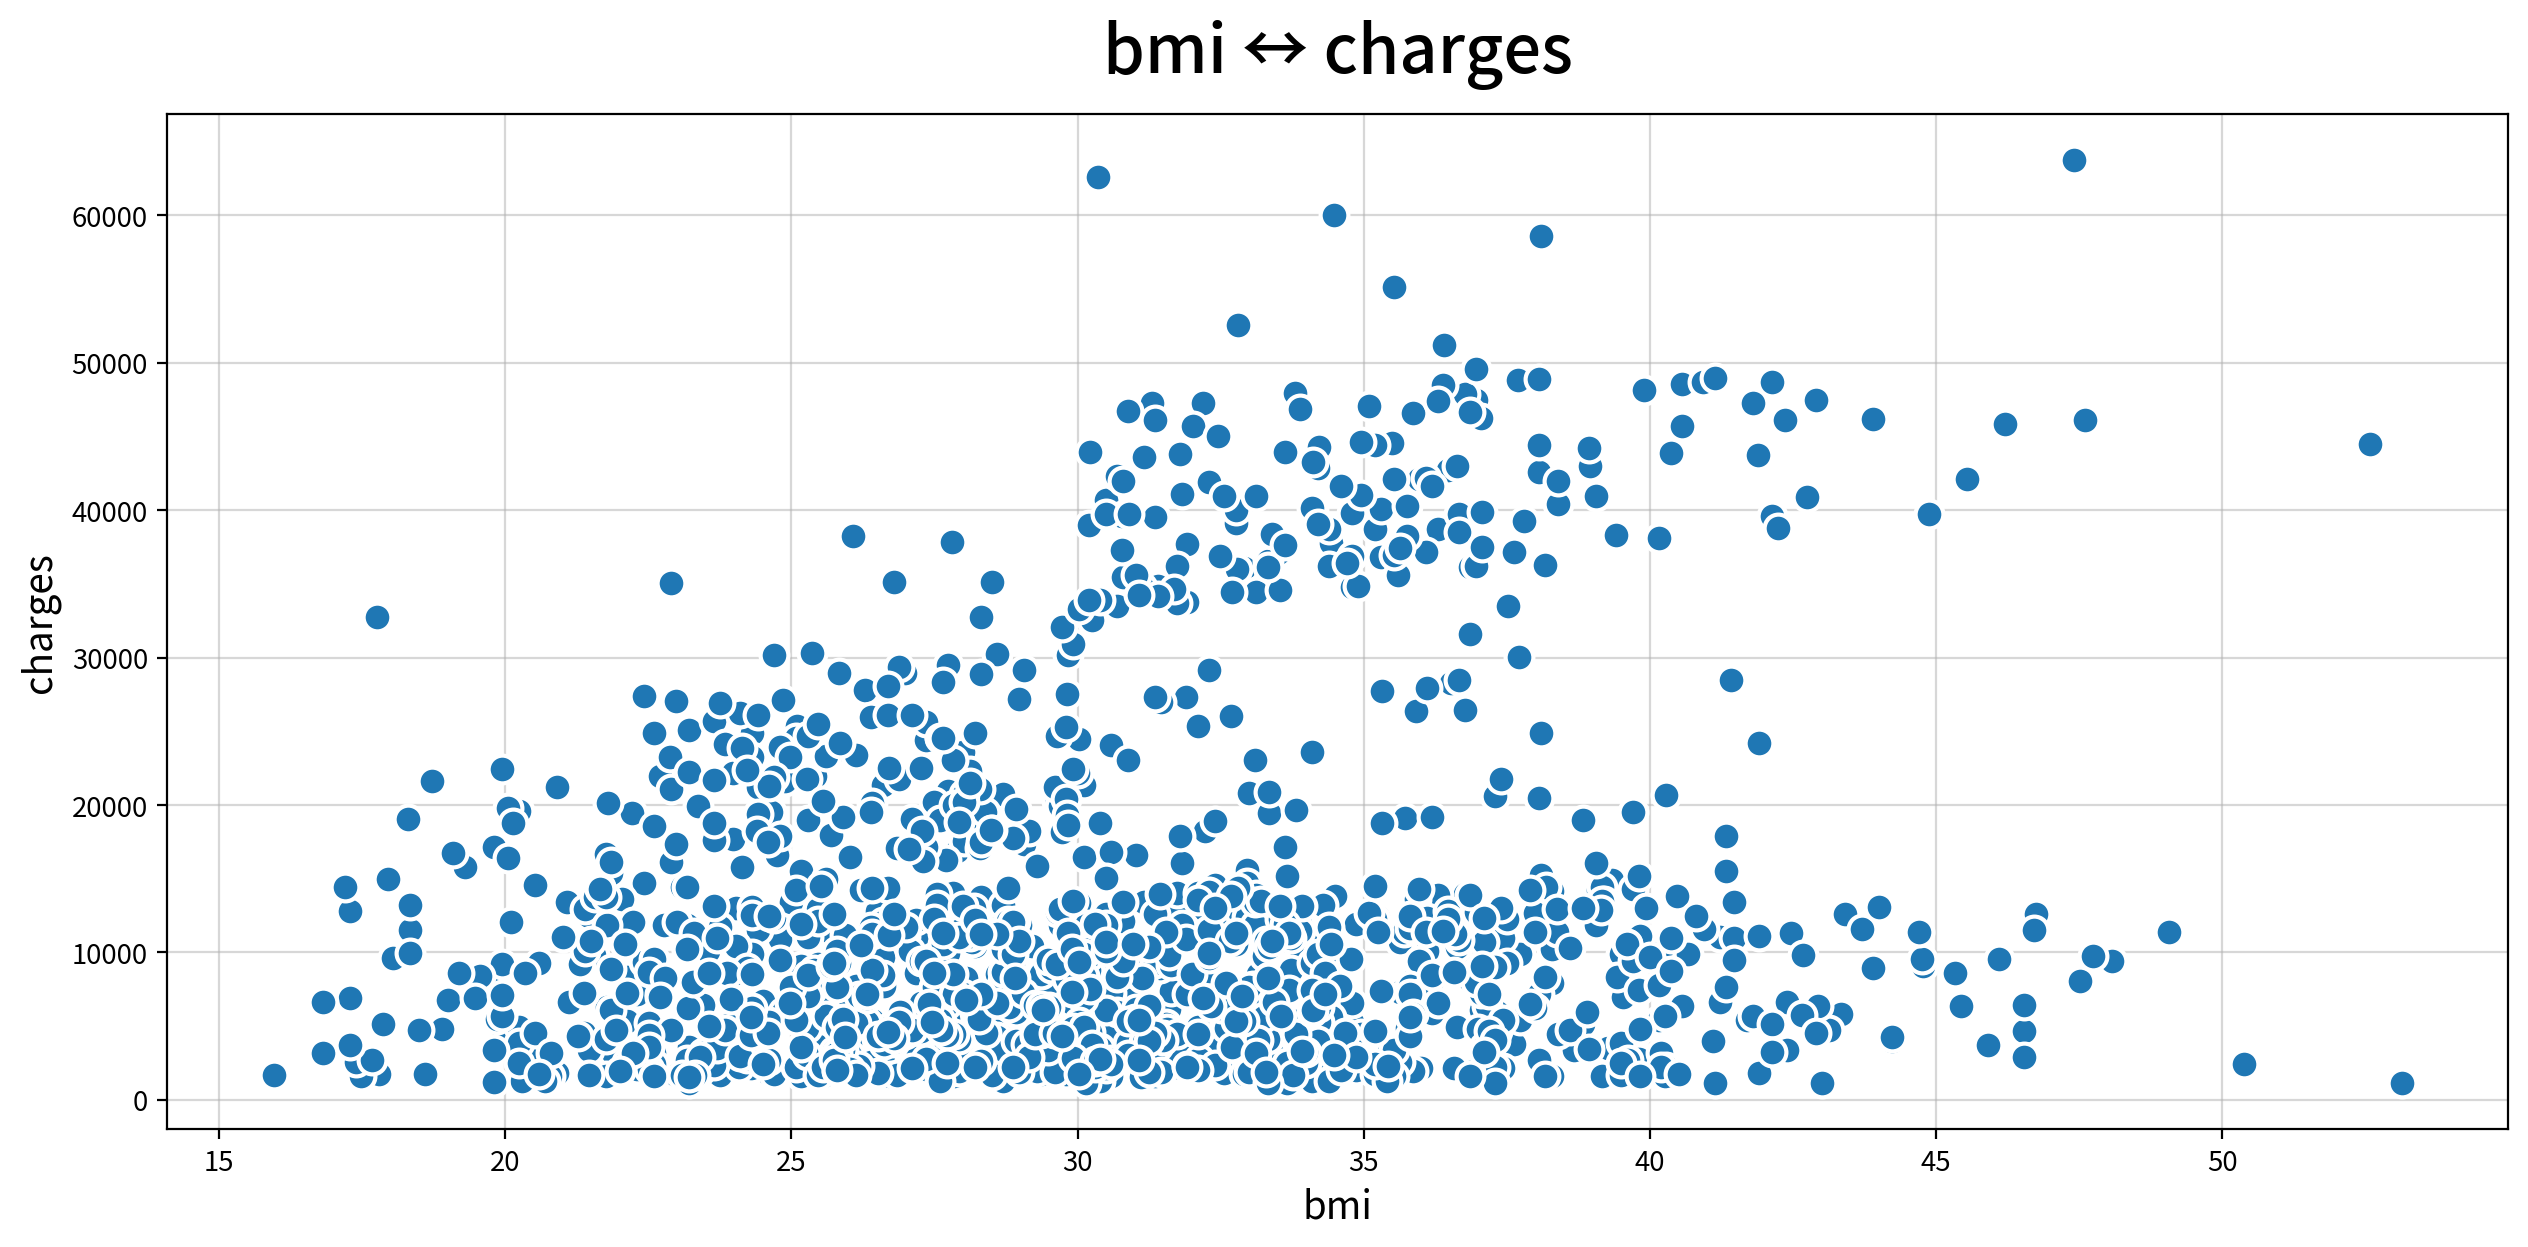

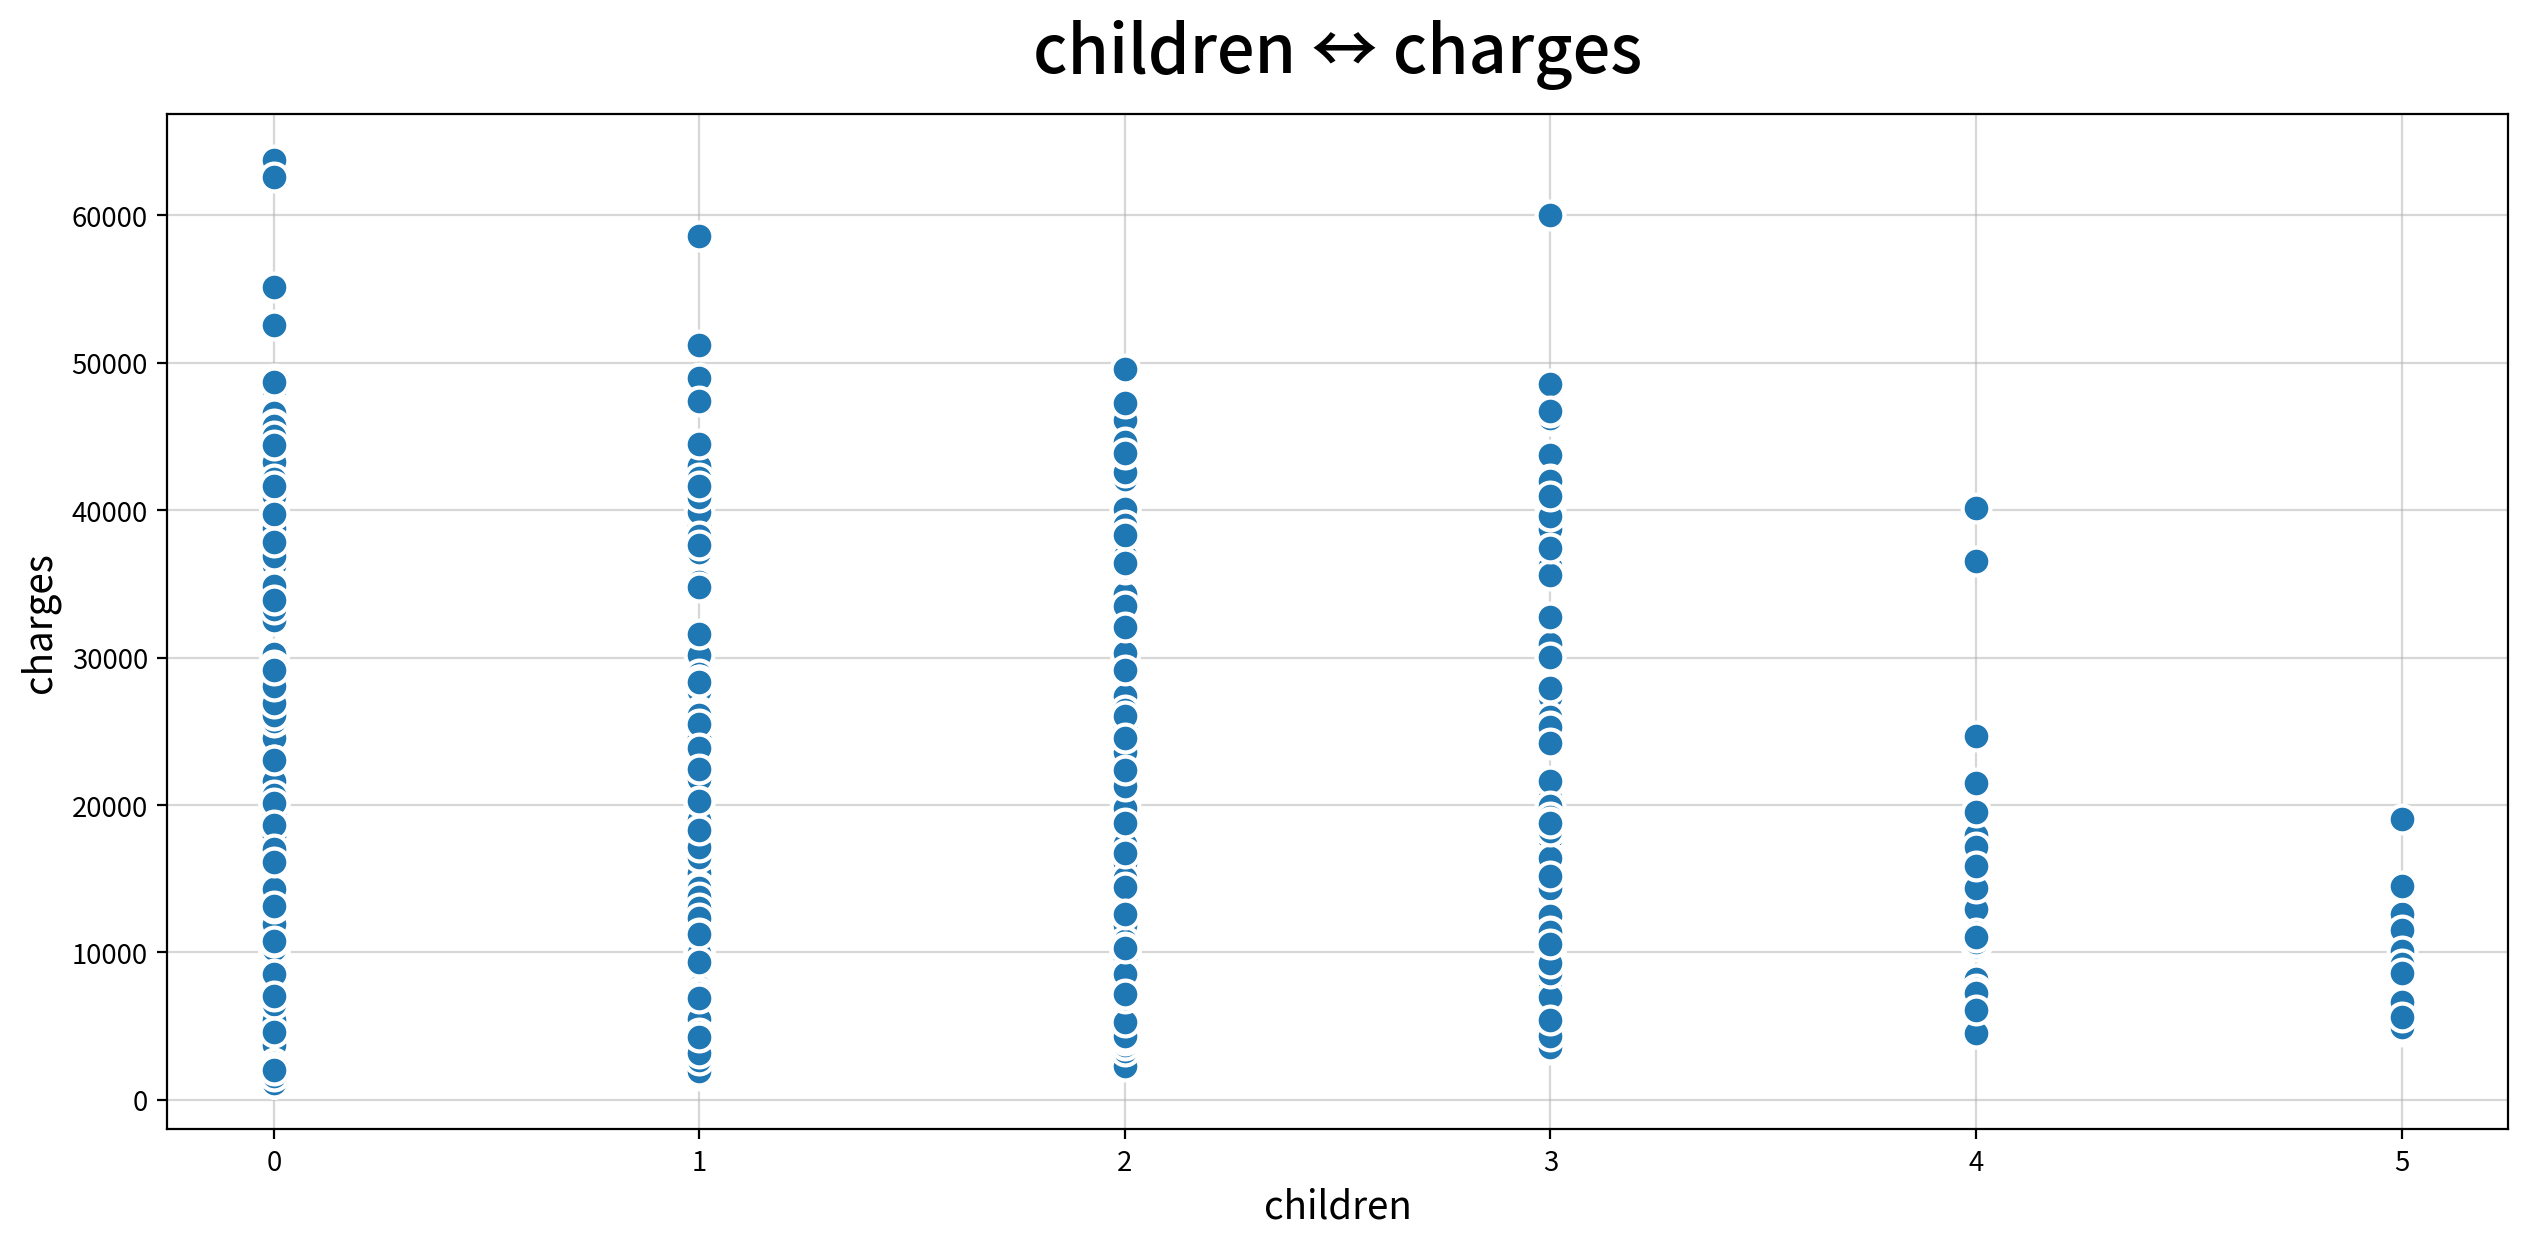

In [38]:
for f in feature_continuous:
    # 연속 ↔ 연속: 산점도로 방향, 모양, 산포를 확인
    my_plot.scatterplot(data=df, x=f, y=target, title=f'{f} ↔ {target}')

- 인사이트
- 연속 X 연속 → 산점도, 짝이 되는 검정은 상관분석(방향, 모양, 산포를 함께 본다)

|변수|관찰된 관계(방향, 모양)|→검정|
|-|-|-|
|age|뚜렷한 양(+)(나이 ↑ → 보험료 ↑)|상관분석|
|bmi|약한 양(+)(산포 큼)|상관분석|
|children|거의 없음 혹은 아주 약한 양(+)(가장 낮은 보험료가 아이가 많은수록 약간씩 상승함)|상관분석|

#### 명목형 독립변수 ↔ 종속변수(박스플롯, 바이올린 → T검정)

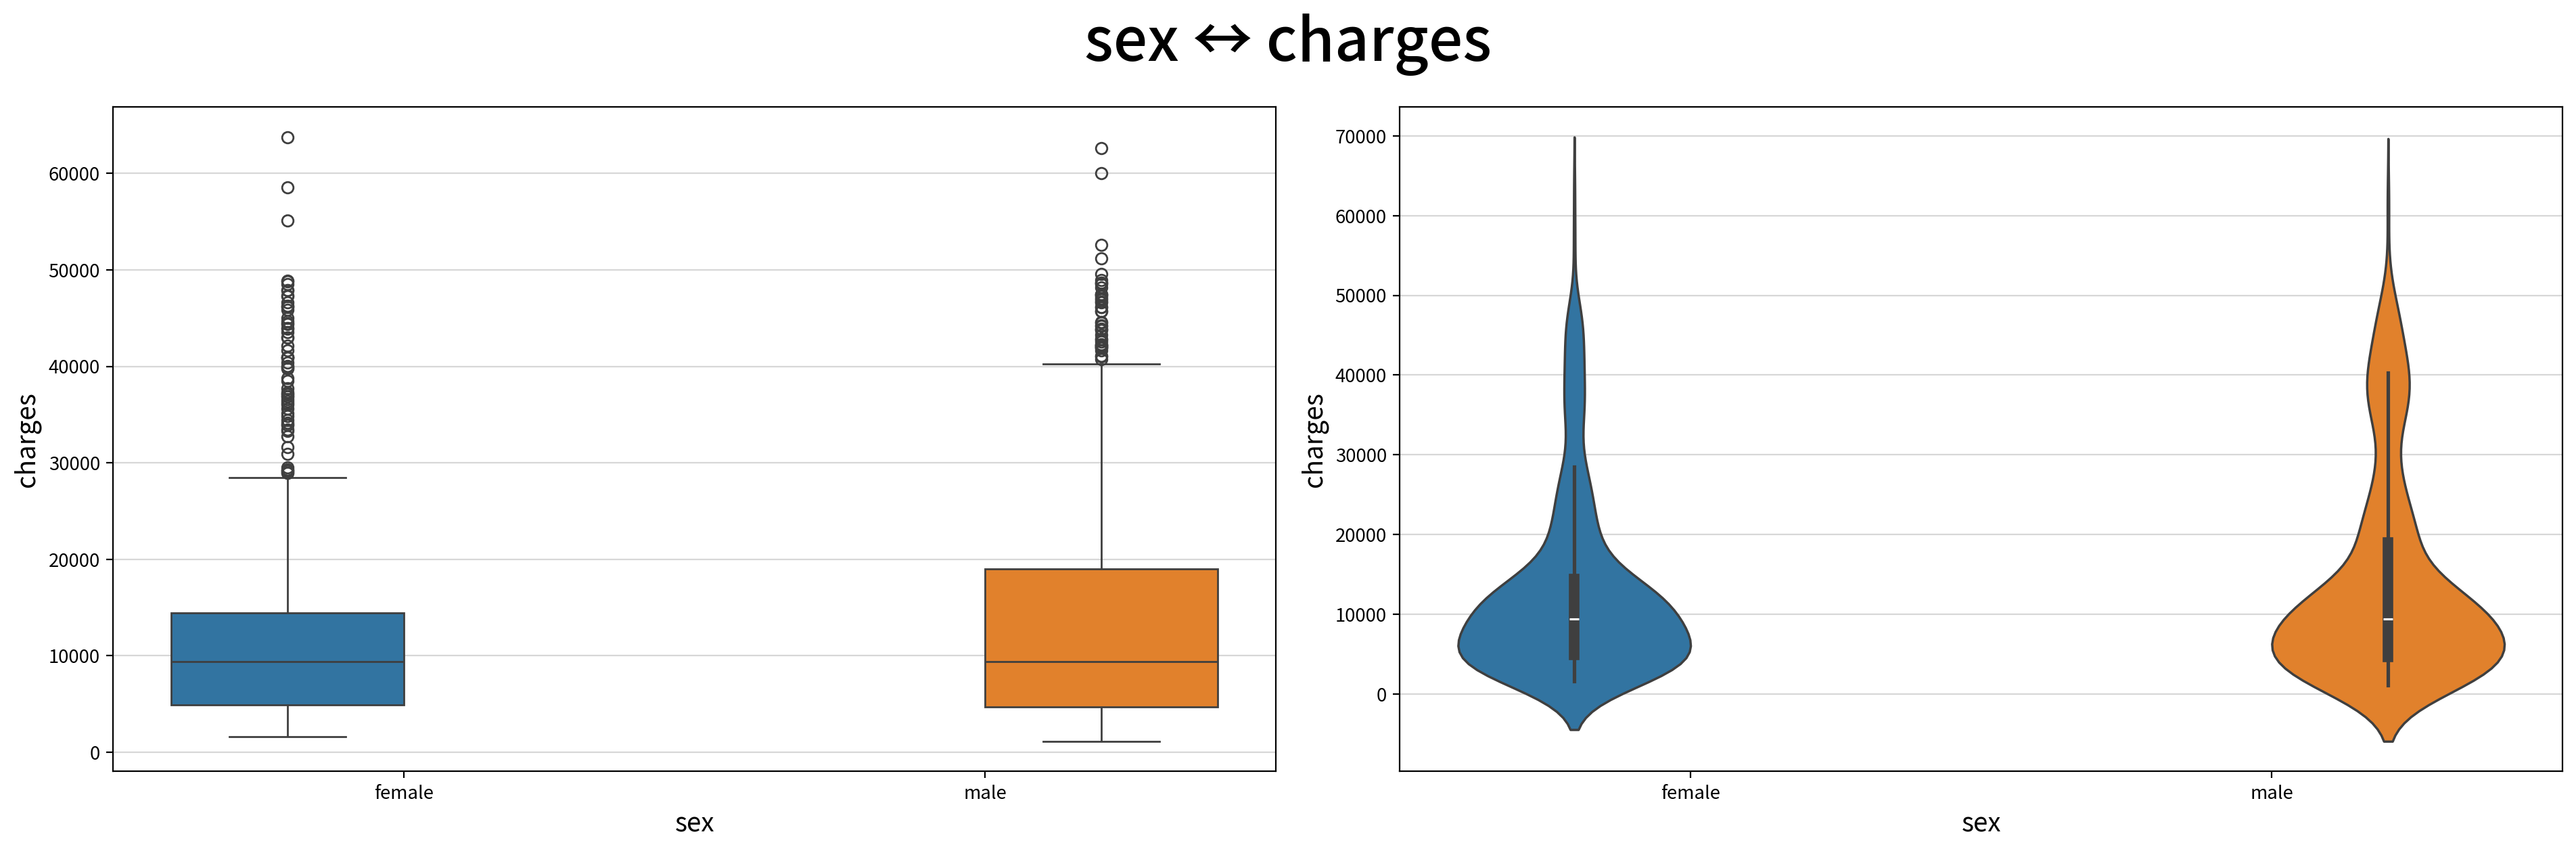

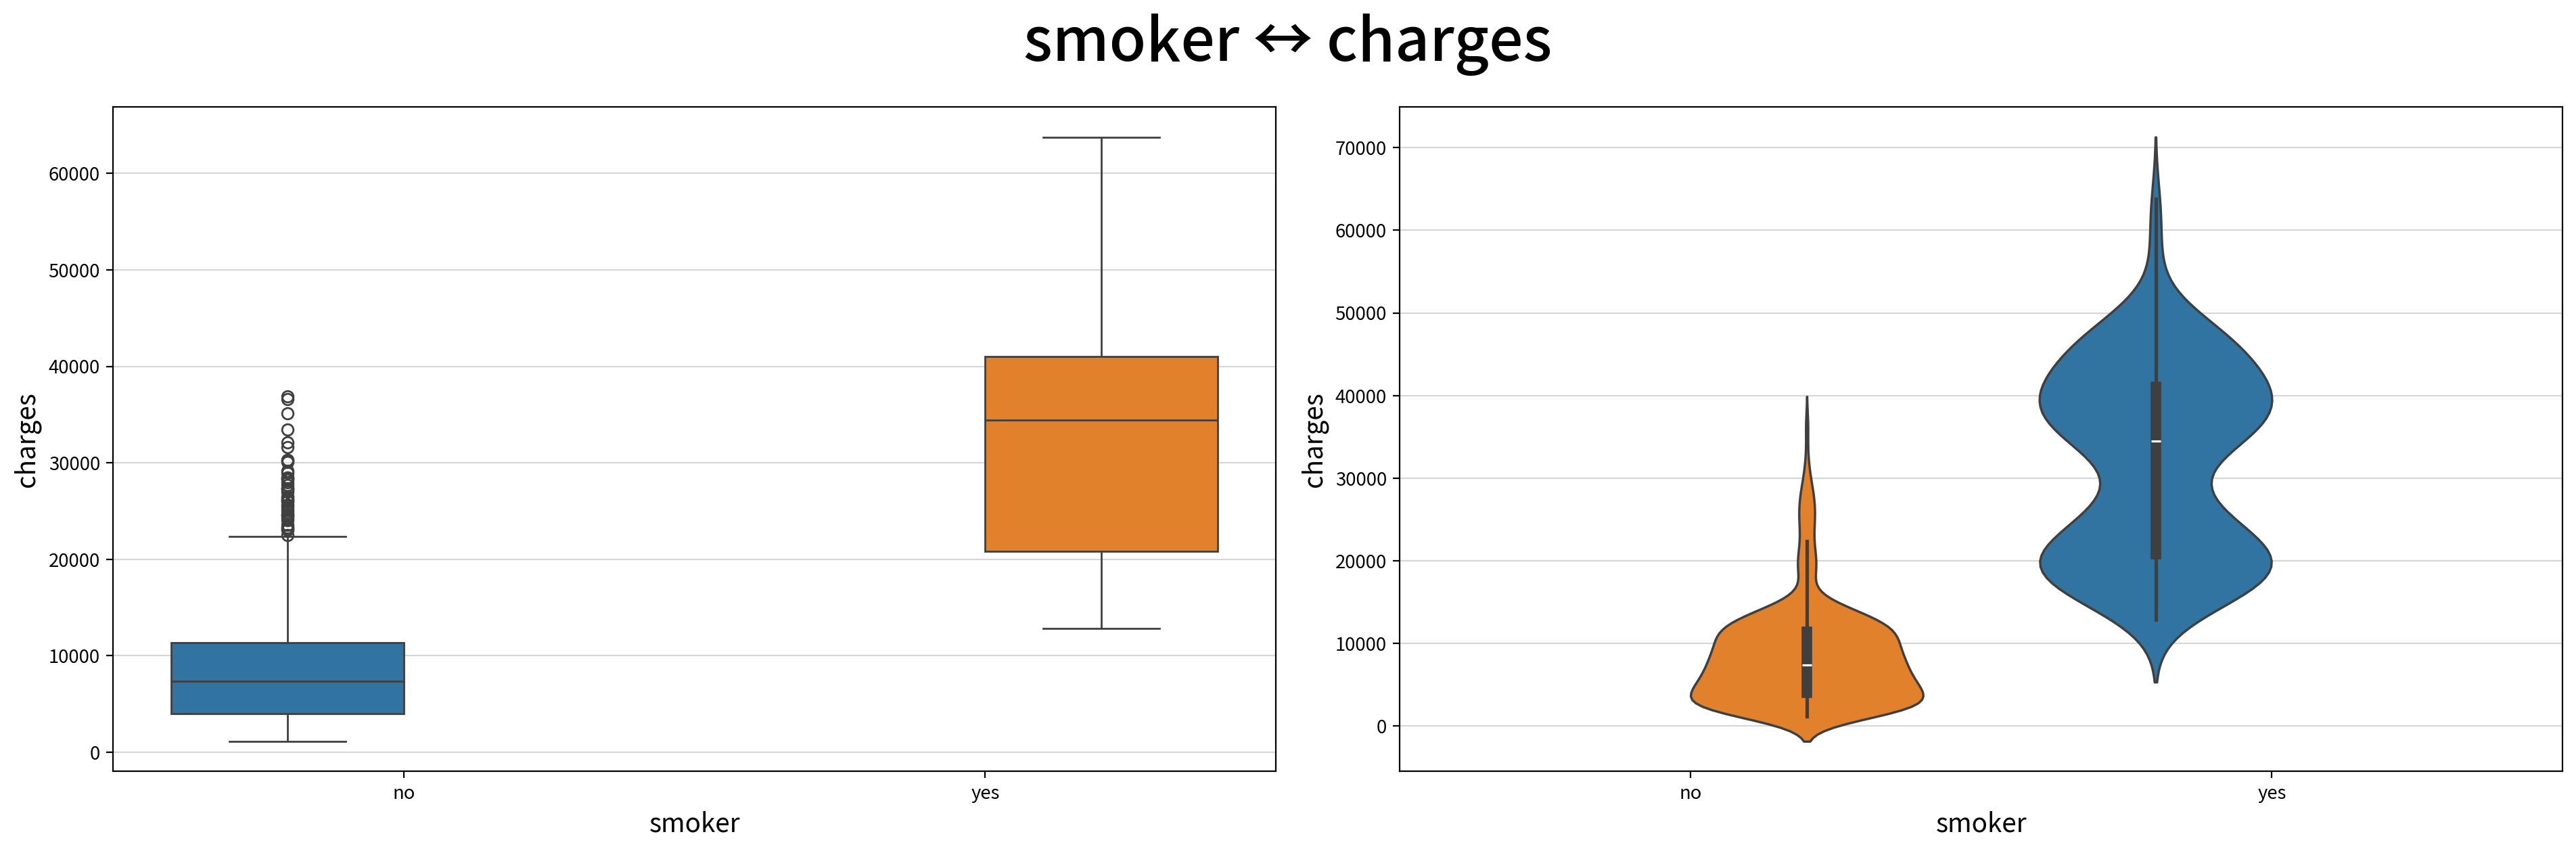

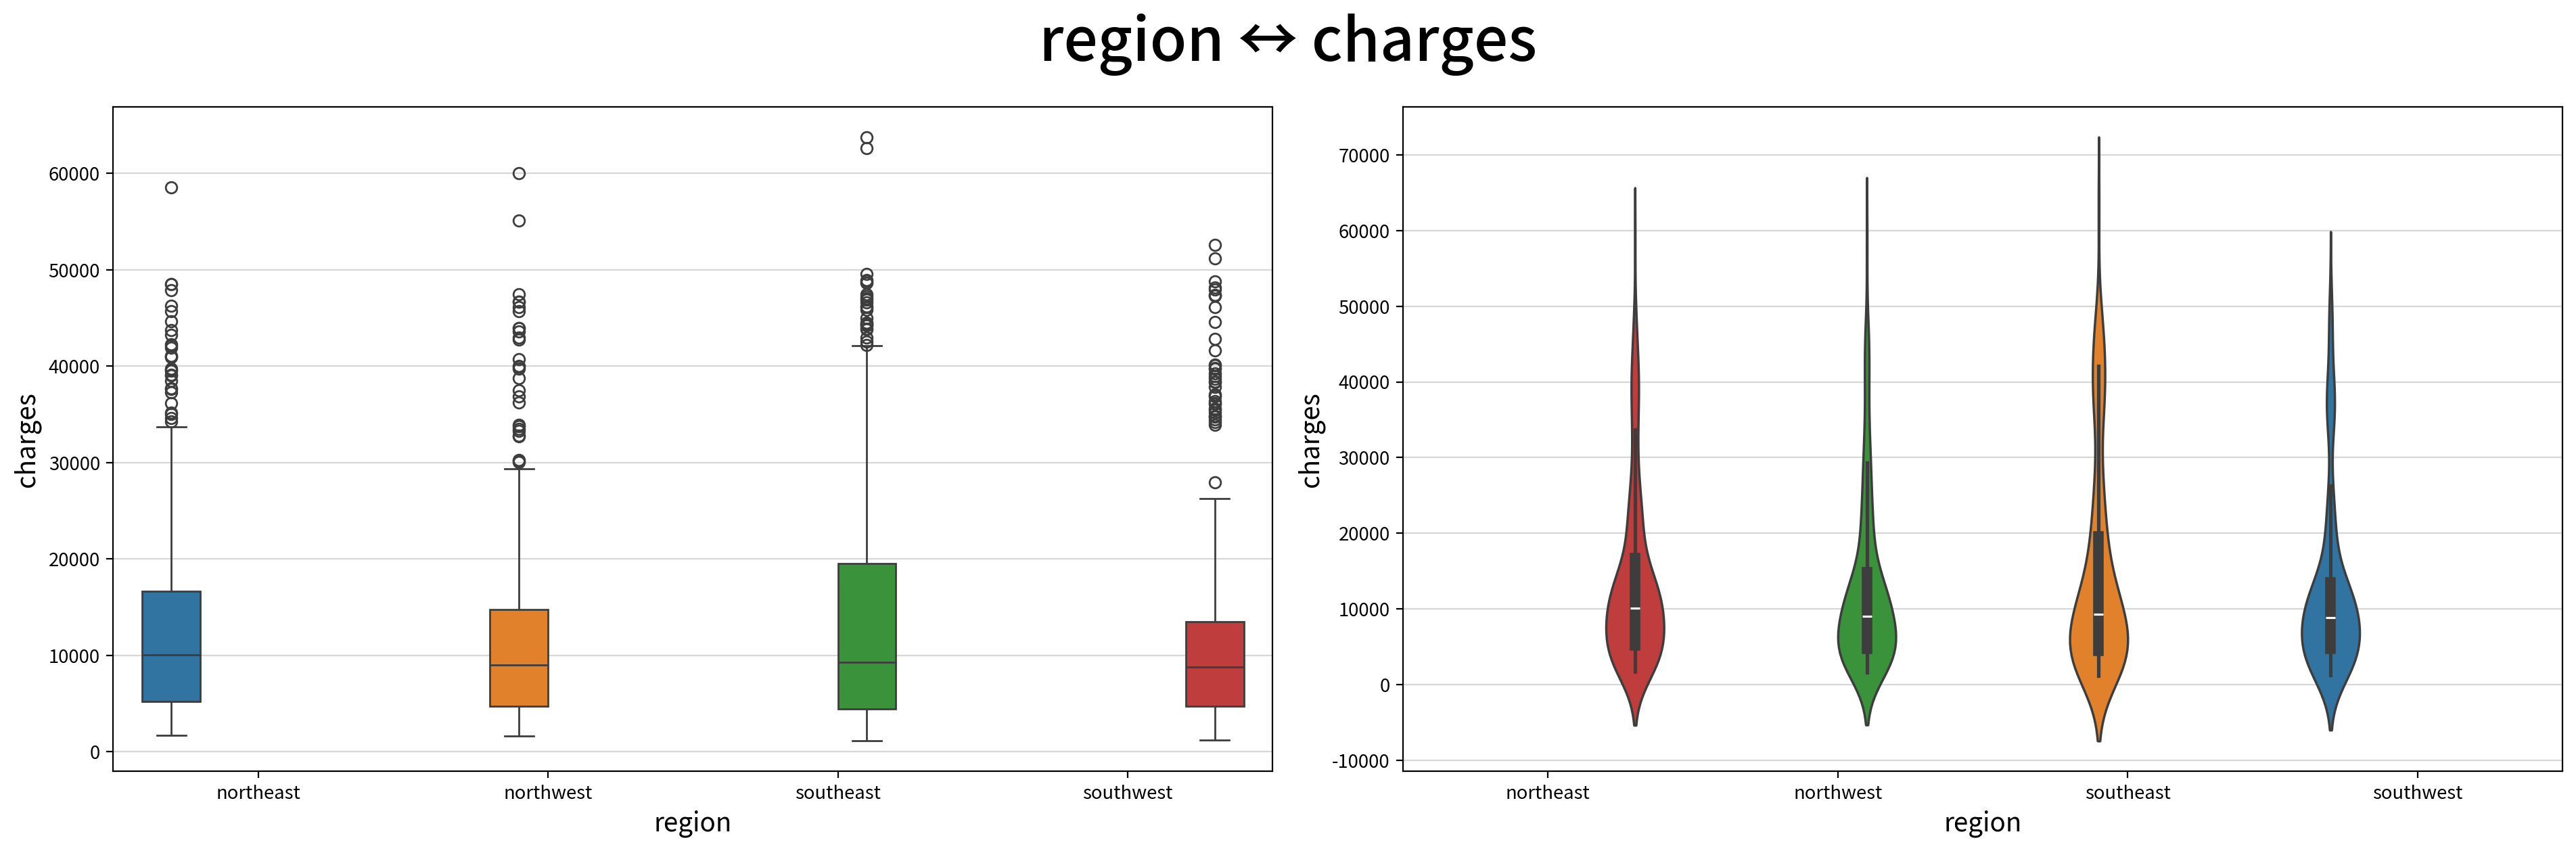

In [39]:
for n in nominal_cols:
    # 명목(2집단) ↔ 연속 : 박스플롯 + 바이올린으로 그룹 간 분포 비교
    fig, ax = my_plot.init(rows=1, cols=2, title=f'{n} ↔ {target}', width=960, height=640)
    my_plot.boxplot(data=df, x=n, y=target, hue=n, ax=ax[0])
    my_plot.violinplot(data=df, x=n, y=target, hue=n, ax=ax[1])
    my_plot.show()

- 인사이트
- 명목(2집단) X 연속 → 박스플롯/바이올린, 짝이 되는 검정은 T검정
- 명목(3집단 이상) X 연속 → 박스플롯/바이올린, 짝이 되는 검정은 ANOVA

|변수|관찰된 관계(방향)|→ 검정|
|-|-|-|
|sex|male의 charges 분포가 female보다 약간 위쪽|T검정|
|smoker|yes의 charges 중앙값이 no보다 뚜렷하게 높고 분포가 위쪽 → 흡연자 > 비흡연자|T검정|
|region|지역별 charges 중앙값과 분포가 대체로 비슷함 → 지역 차이 뚜렷하지 않음|ANOVA|

- sex는 male과 female의 중앙값 차이가 아주 크지는 않지만, male 쪽에서 분포 범위가 더 넓다.
- 흡연자(smoker=yes)의 보험료가 비흡연자(smoker=no)보다 뚜렷하게 높다.
- smoker는 no 집단이 더 많고 yes 집단은 상대적으로 적지만, 박스플롯/바이올린에서 두 집단의 charges 차이가 크게 관찰된다.
- 지역(region)에 따른 보험료 차이는 크지 않아 보인다.
- 네 지역 모두 낮은 보험료 구간에 많이 분포하고, 고액 보험료 이상치는 여러 지역에서 관찰된다.
- 아직 눈으로 본 후보이므로, 실제 유의성, 효과크기는 추론통계 단계의 T검정 및 ANOVA에서 확정한다.

#### 다변량 데이터 시각화

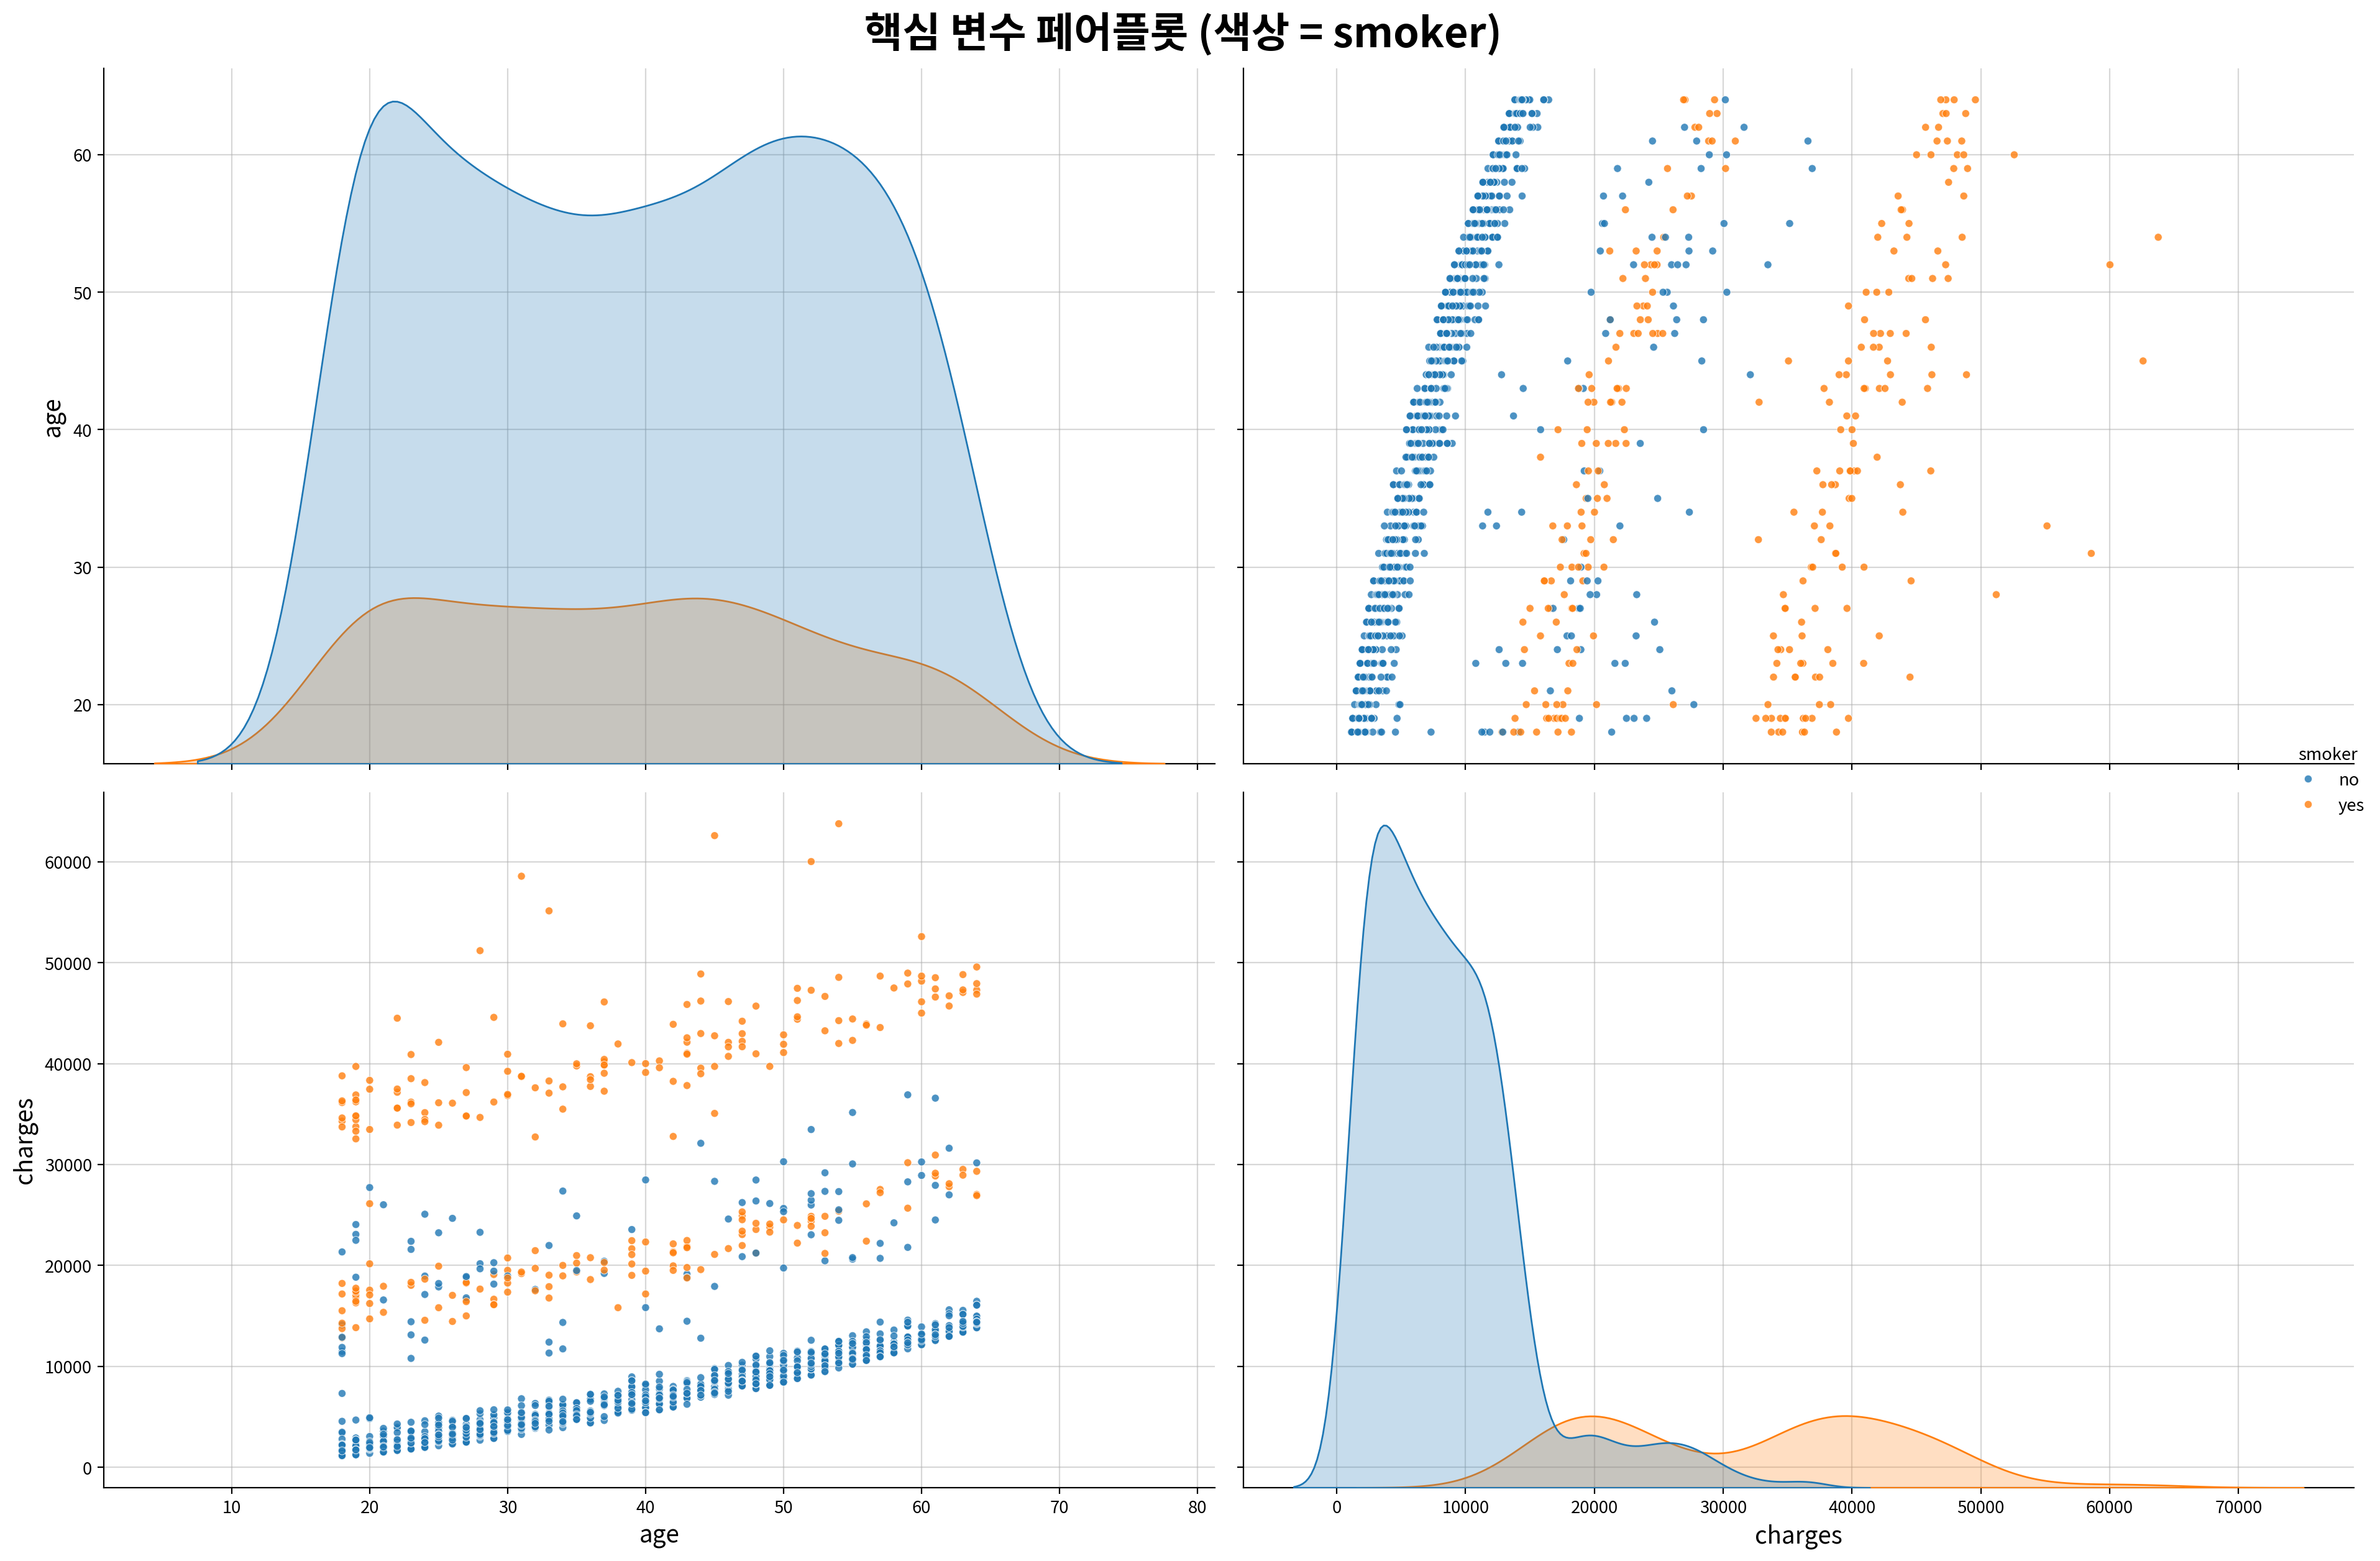

In [43]:
# 핵심변수 페어플롯 - 대각=분포(KDE), 비대각=산점도, 색상=명목형(CHAS)
# 이변량에서 관계가 뚜렷했던 변수 + 종속변수만 선택(12개 전부는 정보 과부하)
core_cols = ['age', target]
hue_col = 'smoker'
my_plot.pairplot(data=df[core_cols + [hue_col]], hue=hue_col, diag_kind='kde', title=f'핵심 변수 페어플롯 (색상 = {hue_col})', width=480*4, height=320*4)

- 페어플롯으로 핵심변수들의 분포(대각)와 두 변수 관계(비대각)를 한번에 확인한다.
- charges 관계 : age는 charges와 양(+) 경향을 보인다. 즉 나이가 증가할수록 보험료가 증가하는 패턴이 관찰된다.
- 색상(smoker): 같은 age 구간에서도 smoker=yes 점들이 charges 위쪽(고액 보험료)에 뚜렷하게 분포한다 > 흡연자가 비흡연자보다 보험료가 높다는 후보 패턴 보강
- smoker 관계 : smoker=no는 낮은 보험료 구간에 많이 몰려 있고, smoker=yes는 중간~고액 보험료 구간까지 넓게 분포한다 > 흡연 여부가 charges 차이를 크게 나누는 핵심 변수 후보로 볼 수 있음
- 설명 변수끼리의 관계 : age와 smoker 사이에는 뚜렷한 선형 관계가 보이지 않는다 > 나이와 흡연 여부의 중복 가능성은 크지 않아 보임
- 여기까지는 모두 눈으로 본 후보다. 상관계수, 유의성 등 숫자 근거는 추론통계의 상관분석과 T검정에서 확정한다.

### 추론통계 후보 패턴 목록

|#|변수조합(유형)|관찰된 패턴(방향, 근거 그래프)|→ 검정|
|-|-|-|-|
|01|age, charges(연속X연속)|age ↑ → charges ↑, 양(+) 경향이 비교적 뚜렷함(산점도, 페어플롯)|상관분석|
|02|bmi, charges(연속X연속)|bmi ↑ → charges ↑, 약한 양(+) 경향이나 산포 큼(산점도)|상관분석|
|03|children, charges(연속X연속)|뚜렷한 선형 관계는 약함, 값이 0~5명으로 분리됨(산점도)|상관분석|
|04|sex, charges(명목2집단 X 연속)|male의 charges 분포가 female보다 약간 위쪽(박스, 바이올린)|T검정|
|05|smoker, charges(명목2집단 X 연속)|smoker=yes 집단의 charges 중앙값과 분포가 no보다 뚜렷하게 높음 = 흡연자 > 비흡연자(박스, 바이올린, 페어플롯)|T검정|
|06|region, charges(명목4집단 X 연속)|지역별 charges 중앙값과 분포가 대체로 비슷함, 뚜렷한 차이는 약함(박스, 바이올린)|ANOVA|